# Healthcare EDA v2 — Deep-Dive Analytics & Stakeholder Dashboard

**Purpose:** Deep-dive into 5 critical areas identified in v1 to drive actionable insights for healthcare stakeholders.

| # | Focus Area | Key Question |
|---|---|---|
| 1 | Readmission Risk (LACE) | Which patients are at highest risk of readmission? |
| 2 | Surgical Profitability | Which DRGs/specialties drive profit vs loss? |
| 3 | Quality Compliance Trends | Are quality measures improving over time? |
| 4 | Patient Risk Stratification | Which demographic segments carry highest risk? |
| 5 | Hospital Benchmarking | How do hospitals compare on key metrics? |

**Database:** `HealthcareDB.db` — 13 tables | **Source:** `Healthcare_EDA.ipynb` (v1)

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})
PALETTE = sns.color_palette('Set2', 10)

DB_PATH = r'C:\Users\aysharma\Desktop\Projects\Old_Projects\Text_to_SQL_ChatBot\database\HealthcareDB.db'
conn = sqlite3.connect(DB_PATH)

def load(name):
    return pd.read_sql_query(f'SELECT * FROM [{name}]', conn)

print('Database connected.')

Database connected.


In [2]:
patients    = load('Patients')
encounters  = load('Encounters')
accounts    = load('Accounts')
surg_enc    = load('SurgicalEncounters')
surg_costs  = load('SurgicalCosts')
quality     = load('QualityMeasureData')
vitals      = load('Vitals')
hospitals   = load('Hospitals')
departments = load('Departments')
orders      = load('OrdersProcedures')
results     = load('Results')
physicians  = load('Physicians')

# Date parsing
patients['Patient DOB'] = pd.to_datetime(patients['Patient DOB'], errors='coerce')
encounters['Admission Dt'] = pd.to_datetime(encounters['Patient Admission Datetime'], errors='coerce')
encounters['Discharge Dt'] = pd.to_datetime(encounters['Patient Discharge Datetime'], errors='coerce')
surg_enc['Admission Dt'] = pd.to_datetime(surg_enc['Surgical Admission Date'], errors='coerce')
surg_enc['Discharge Dt'] = pd.to_datetime(surg_enc['Surgical Discharge Date'], errors='coerce')
quality['Effective Dt'] = pd.to_datetime(quality['Measure Effective Date'], errors='coerce')
quality['End Dt'] = pd.to_datetime(quality['Measure End Date'], errors='coerce')

# Derived columns
patients['Age'] = ((pd.Timestamp('2016-01-01') - patients['Patient DOB']).dt.days / 365.25).round(0)
patients['Age Group'] = pd.cut(patients['Age'], bins=[0, 30, 50, 65, 80, 120],
                               labels=['<30', '30-50', '50-65', '65-80', '80+'])
encounters['Month'] = encounters['Admission Dt'].dt.month
encounters['Quarter'] = encounters['Admission Dt'].dt.quarter
surg_enc['Profit Margin %'] = (surg_enc['Surgical Total Profit'] / surg_enc['Surgical Total Cost'] * 100).round(1)

# Encode flags
encounters['Readmit'] = encounters['Patient Readmission Flag'].map({'Yes': 1, 'No': 0})
encounters['ICU'] = encounters['Patient InICU Flag'].map({'Yes': 1, 'No': 0})
quality['Compliant'] = quality['IsCompliant'].map({'Yes': 1, 'No': 0})

# Hospital lookup from departments
dept_hosp = departments[['Department ID', 'Hospital ID']].drop_duplicates()
hosp_lookup = hospitals[['Hospital ID', 'Hospital Name', 'Hospital City', 'Hospital County']].drop_duplicates()

print(f'Loaded {len(patients)} patients | {len(encounters)} encounters | {len(surg_enc)} surgeries | {len(quality)} quality records')

Loaded 100 patients | 100 encounters | 100 surgeries | 100 quality records


---
## 1. Readmission Risk — LACE Score Deep Dive

The **LACE Index** predicts 30-day readmission risk based on **L**ength of stay, **A**cuity of admission, **C**omorbidities, and **E**mergency department visits. Score range: 0-19, with higher = greater risk.

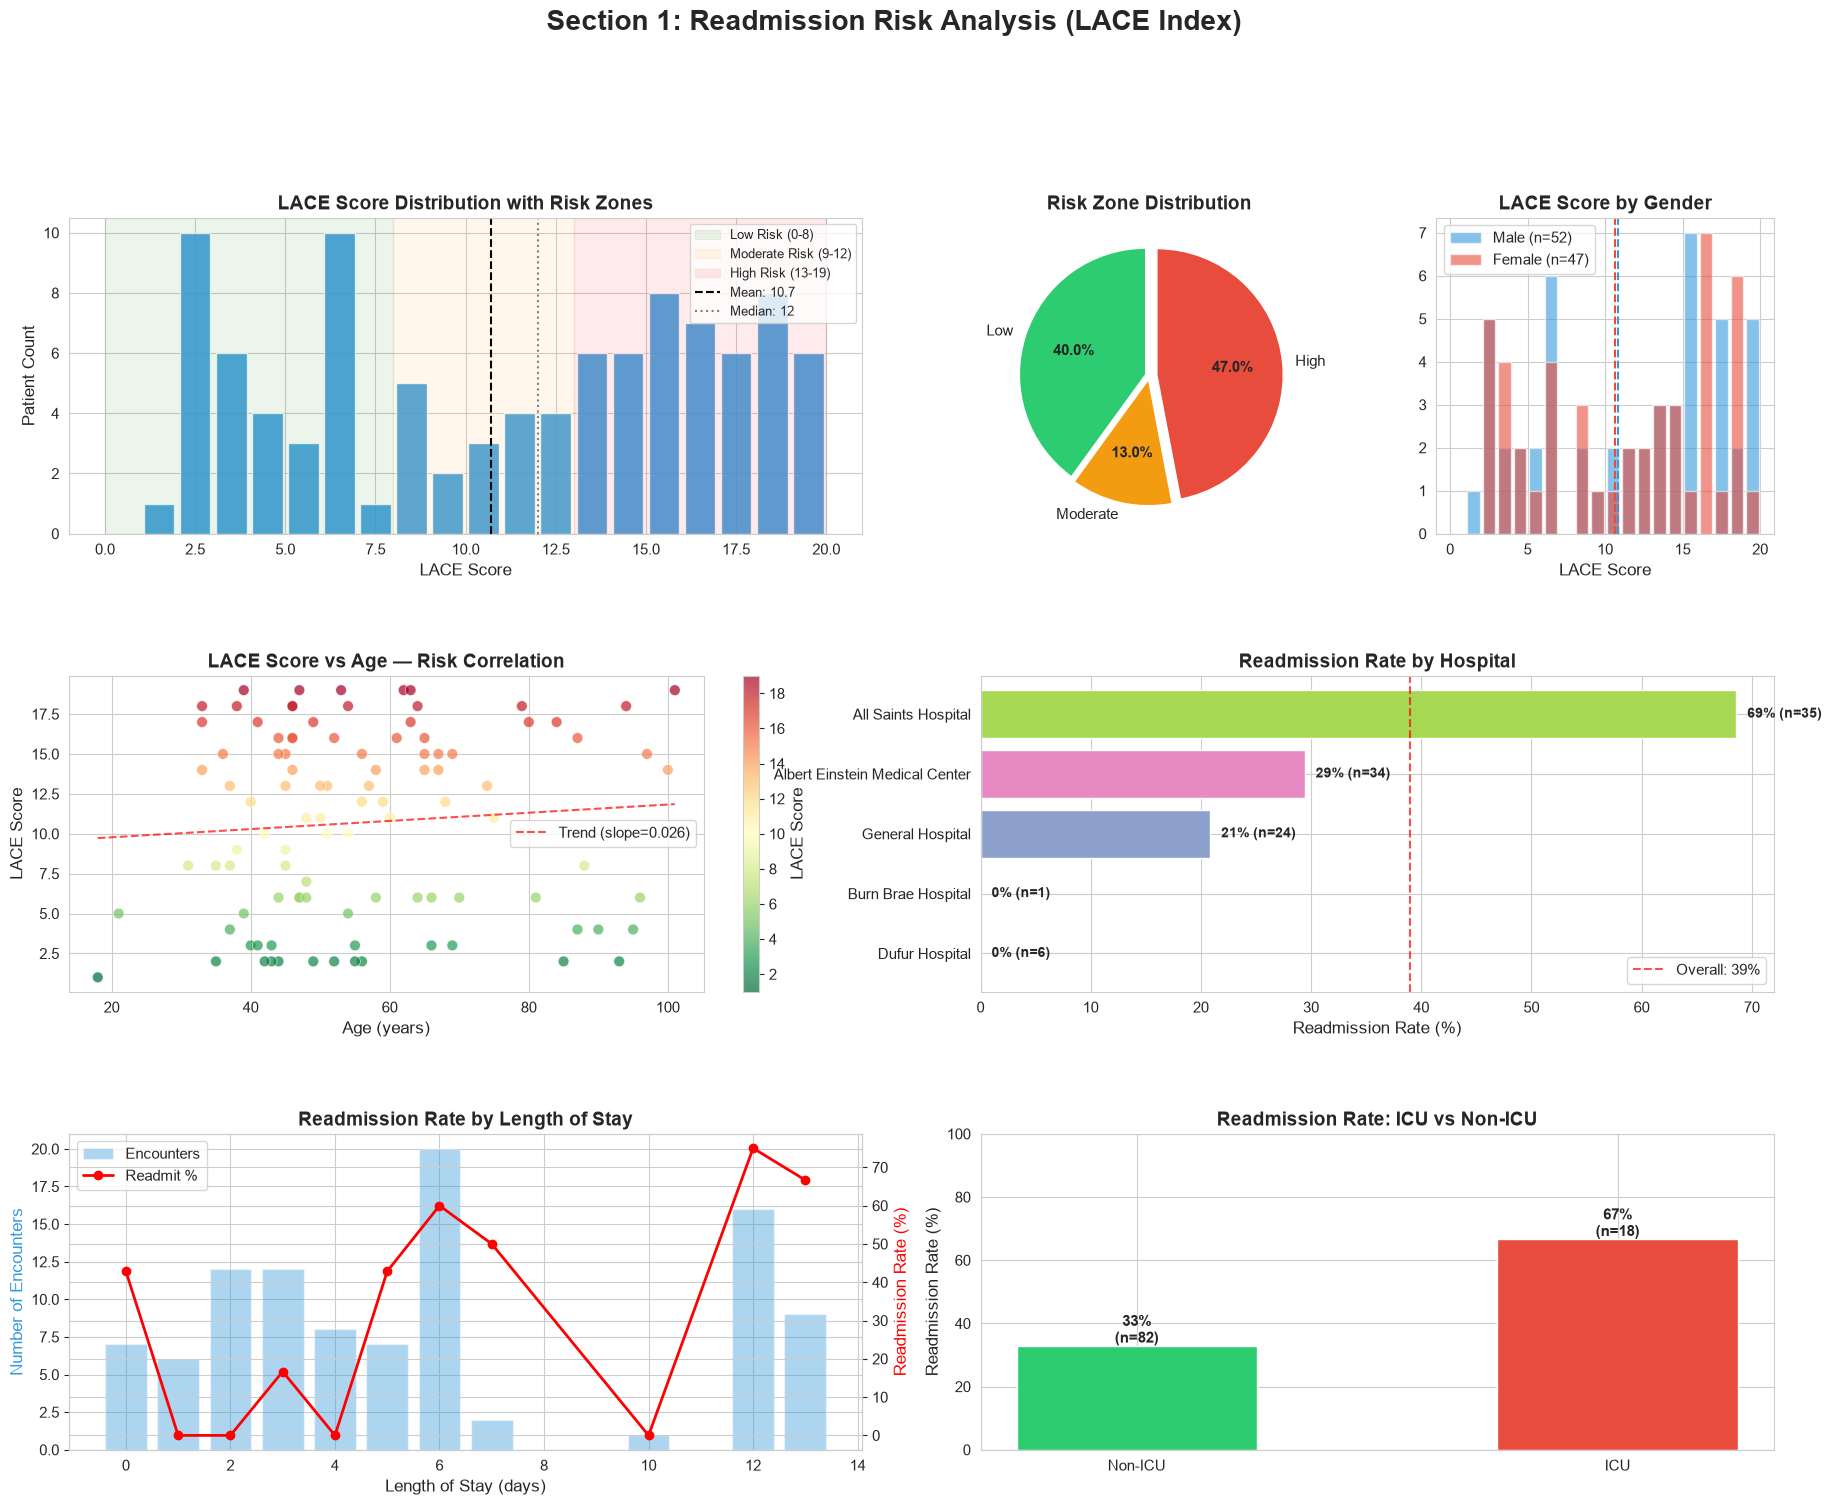

In [3]:
fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(3, 4, hspace=0.45, wspace=0.35)

# ── 1A: LACE Score Distribution ──
ax1 = fig.add_subplot(gs[0, 0:2])
lace = patients['Patient LACE Score'].dropna()
colors_lace = ['#2ecc71' if s <= 8 else '#f39c12' if s <= 12 else '#e74c3c' for s in lace.sort_values()]
ax1.hist(lace, bins=range(0, 21), color='#3498db', edgecolor='white', alpha=0.85, rwidth=0.85)
ax1.axvspan(0, 8, alpha=0.08, color='green', label='Low Risk (0-8)')
ax1.axvspan(8, 13, alpha=0.08, color='orange', label='Moderate Risk (9-12)')
ax1.axvspan(13, 20, alpha=0.08, color='red', label='High Risk (13-19)')
ax1.axvline(lace.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {lace.mean():.1f}')
ax1.axvline(lace.median(), color='gray', linestyle=':', linewidth=1.5, label=f'Median: {lace.median():.0f}')
ax1.set_title('LACE Score Distribution with Risk Zones', fontweight='bold')
ax1.set_xlabel('LACE Score')
ax1.set_ylabel('Patient Count')
ax1.legend(fontsize=9, loc='upper right')

# ── 1B: Risk Zone Breakdown ──
ax2 = fig.add_subplot(gs[0, 2])
risk_zones = pd.cut(lace, bins=[-1, 8, 12, 19], labels=['Low', 'Moderate', 'High'])
rz_counts = risk_zones.value_counts().reindex(['Low', 'Moderate', 'High'])
wedges, texts, autotexts = ax2.pie(rz_counts, labels=rz_counts.index, autopct='%1.1f%%',
                                    colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90,
                                    explode=[0.03, 0.03, 0.06])
for t in autotexts:
    t.set_fontweight('bold')
ax2.set_title('Risk Zone Distribution', fontweight='bold')

# ── 1C: LACE by Gender ──
ax3 = fig.add_subplot(gs[0, 3])
for g, c in zip(['Male', 'Female'], ['#3498db', '#e74c3c']):
    subset = patients[patients['Patient Gender'] == g]['Patient LACE Score'].dropna()
    ax3.hist(subset, bins=range(0, 21), alpha=0.6, label=f'{g} (n={len(subset)})', color=c, rwidth=0.8)
ax3.axvline(patients[patients['Patient Gender']=='Male']['Patient LACE Score'].mean(), color='#3498db', linestyle='--')
ax3.axvline(patients[patients['Patient Gender']=='Female']['Patient LACE Score'].mean(), color='#e74c3c', linestyle='--')
ax3.set_title('LACE Score by Gender', fontweight='bold')
ax3.set_xlabel('LACE Score')
ax3.legend()

# ── 1D: LACE vs Age Scatter ──
ax4 = fig.add_subplot(gs[1, 0:2])
scatter = ax4.scatter(patients['Age'], patients['Patient LACE Score'],
                      c=patients['Patient LACE Score'], cmap='RdYlGn_r',
                      s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.colorbar(scatter, ax=ax4, label='LACE Score')
z = np.polyfit(patients['Age'].dropna(), patients['Patient LACE Score'].dropna(), 1)
p = np.poly1d(z)
age_range = np.linspace(patients['Age'].min(), patients['Age'].max(), 100)
ax4.plot(age_range, p(age_range), 'r--', alpha=0.7, label=f'Trend (slope={z[0]:.3f})')
ax4.set_title('LACE Score vs Age — Risk Correlation', fontweight='bold')
ax4.set_xlabel('Age (years)')
ax4.set_ylabel('LACE Score')
ax4.legend()

# ── 1E: Readmission Rate by Hospital ──
ax5 = fig.add_subplot(gs[1, 2:4])
enc_hosp = encounters.merge(dept_hosp, on='Department ID', how='left').merge(hosp_lookup, on='Hospital ID', how='left')
hosp_readmit = enc_hosp.groupby('Hospital Name').agg(
    Readmit_Rate=('Readmit', 'mean'),
    Count=('Patient Encounter ID', 'count'),
    ICU_Rate=('ICU', 'mean')
).sort_values('Readmit_Rate', ascending=True)
bars = ax5.barh(hosp_readmit.index, hosp_readmit['Readmit_Rate'] * 100, color=PALETTE[:len(hosp_readmit)])
for bar, (_, row) in zip(bars, hosp_readmit.iterrows()):
    ax5.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{row["Readmit_Rate"]*100:.0f}% (n={int(row["Count"])})',
             va='center', fontsize=10, fontweight='bold')
ax5.axvline(enc_hosp['Readmit'].mean()*100, color='red', linestyle='--', alpha=0.7, label=f'Overall: {enc_hosp["Readmit"].mean()*100:.0f}%')
ax5.set_title('Readmission Rate by Hospital', fontweight='bold')
ax5.set_xlabel('Readmission Rate (%)')
ax5.legend()

# ── 1F: LOS vs Readmission ──
ax6 = fig.add_subplot(gs[2, 0:2])
los_readmit = enc_hosp.groupby('Patient LOS').agg(
    Readmit_Rate=('Readmit', 'mean'),
    Count=('Readmit', 'count')
).reset_index()
ax6.bar(los_readmit['Patient LOS'], los_readmit['Count'], color='#3498db', alpha=0.4, label='Encounters')
ax6_r = ax6.twinx()
ax6_r.plot(los_readmit['Patient LOS'], los_readmit['Readmit_Rate']*100, 'ro-', linewidth=2, label='Readmit %')
ax6.set_title('Readmission Rate by Length of Stay', fontweight='bold')
ax6.set_xlabel('Length of Stay (days)')
ax6.set_ylabel('Number of Encounters', color='#3498db')
ax6_r.set_ylabel('Readmission Rate (%)', color='red')
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6_r.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# ── 1G: ICU vs Readmission ──
ax7 = fig.add_subplot(gs[2, 2:4])
icu_readmit = enc_hosp.groupby('ICU').agg(
    Readmit=('Readmit', 'mean'),
    Avg_LOS=('Patient LOS', 'mean'),
    Count=('Readmit', 'count')
)
x_pos = [0, 1]
bars_icu = ax7.bar(x_pos, icu_readmit['Readmit']*100, width=0.5, color=['#2ecc71', '#e74c3c'])
ax7.set_xticks(x_pos)
ax7.set_xticklabels(['Non-ICU', 'ICU'])
for bar, (_, row) in zip(bars_icu, icu_readmit.iterrows()):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{row["Readmit"]*100:.0f}%\n(n={int(row["Count"])})',
             ha='center', fontweight='bold', fontsize=11)
ax7.set_title('Readmission Rate: ICU vs Non-ICU', fontweight='bold')
ax7.set_ylabel('Readmission Rate (%)')
ax7.set_ylim(0, 100)

fig.suptitle('Section 1: Readmission Risk Analysis (LACE Index)', fontsize=20, fontweight='bold', y=1.01)
plt.show()

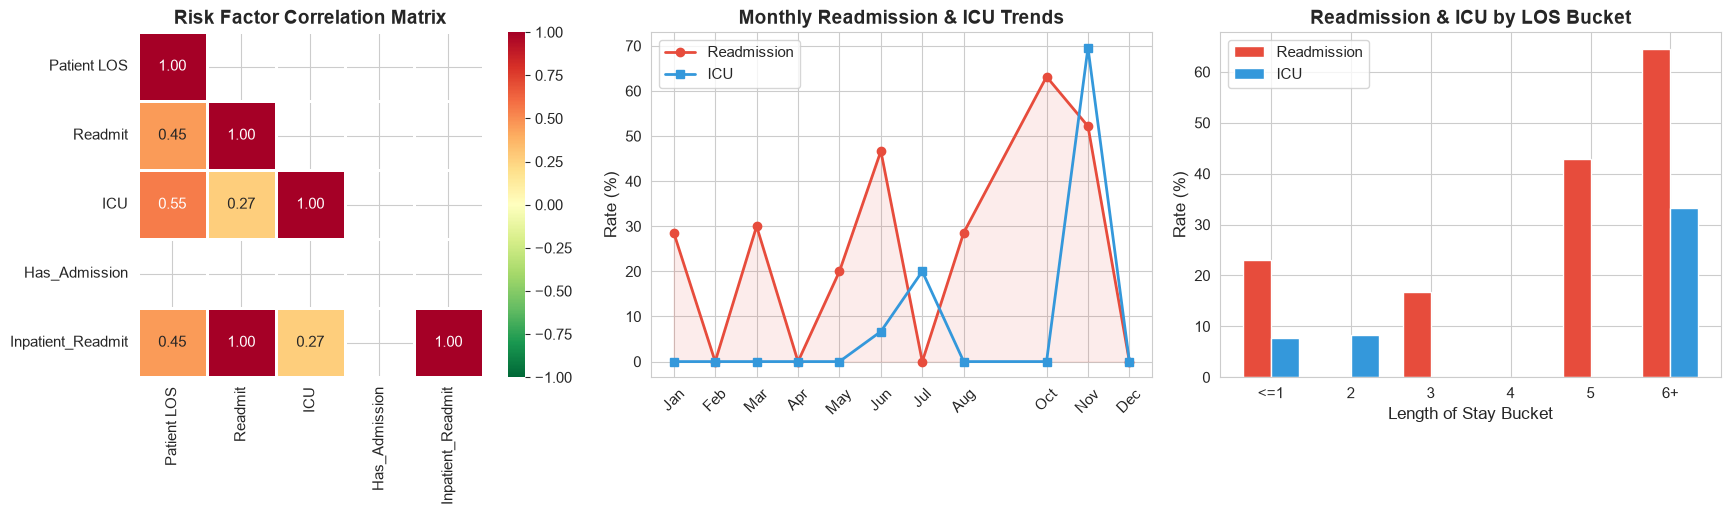

In [4]:
# Risk factor correlation matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Risk factors heatmap
risk_df = encounters[['Patient LOS', 'Readmit', 'ICU']].copy()
risk_df['Has_Admission'] = (encounters['Patient Admitted Flag'] == 'Yes').astype(int)
risk_df['Inpatient_Readmit'] = (encounters['Patient Inpatient Readmission Flag'] == 'Yes').astype(int)
corr = risk_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
            mask=mask, ax=axes[0], square=True, linewidths=1)
axes[0].set_title('Risk Factor Correlation Matrix', fontweight='bold')

# 2. Monthly trend
monthly = encounters.groupby('Month').agg(
    Readmit_Rate=('Readmit', 'mean'),
    ICU_Rate=('ICU', 'mean'),
    Count=('Readmit', 'count')
).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].plot(monthly['Month'], monthly['Readmit_Rate']*100, 'o-', color='#e74c3c', linewidth=2, label='Readmission')
axes[1].plot(monthly['Month'], monthly['ICU_Rate']*100, 's-', color='#3498db', linewidth=2, label='ICU')
axes[1].fill_between(monthly['Month'], monthly['Readmit_Rate']*100, alpha=0.1, color='#e74c3c')
axes[1].set_xticks(monthly['Month'])
axes[1].set_xticklabels([month_names[int(m)-1] for m in monthly['Month']], rotation=45)
axes[1].set_title('Monthly Readmission & ICU Trends', fontweight='bold')
axes[1].set_ylabel('Rate (%)')
axes[1].legend()

# 3. LOS bucket vs readmission
los_bucket_readmit = encounters.groupby('Patient LOS Bucket').agg(
    Readmit=('Readmit', 'mean'),
    ICU=('ICU', 'mean'),
    Count=('Readmit', 'count')
).reindex(['<=1', '2', '3', '4', '5', '6+'])
x = range(len(los_bucket_readmit))
w = 0.35
axes[2].bar([i-w/2 for i in x], los_bucket_readmit['Readmit']*100, w, label='Readmission', color='#e74c3c')
axes[2].bar([i+w/2 for i in x], los_bucket_readmit['ICU']*100, w, label='ICU', color='#3498db')
axes[2].set_xticks(x)
axes[2].set_xticklabels(los_bucket_readmit.index)
axes[2].set_title('Readmission & ICU by LOS Bucket', fontweight='bold')
axes[2].set_ylabel('Rate (%)')
axes[2].set_xlabel('Length of Stay Bucket')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 2. Surgical Profitability — DRG & Specialty Deep Dive

Understanding which procedures generate profit vs loss to guide resource allocation and pricing strategy.

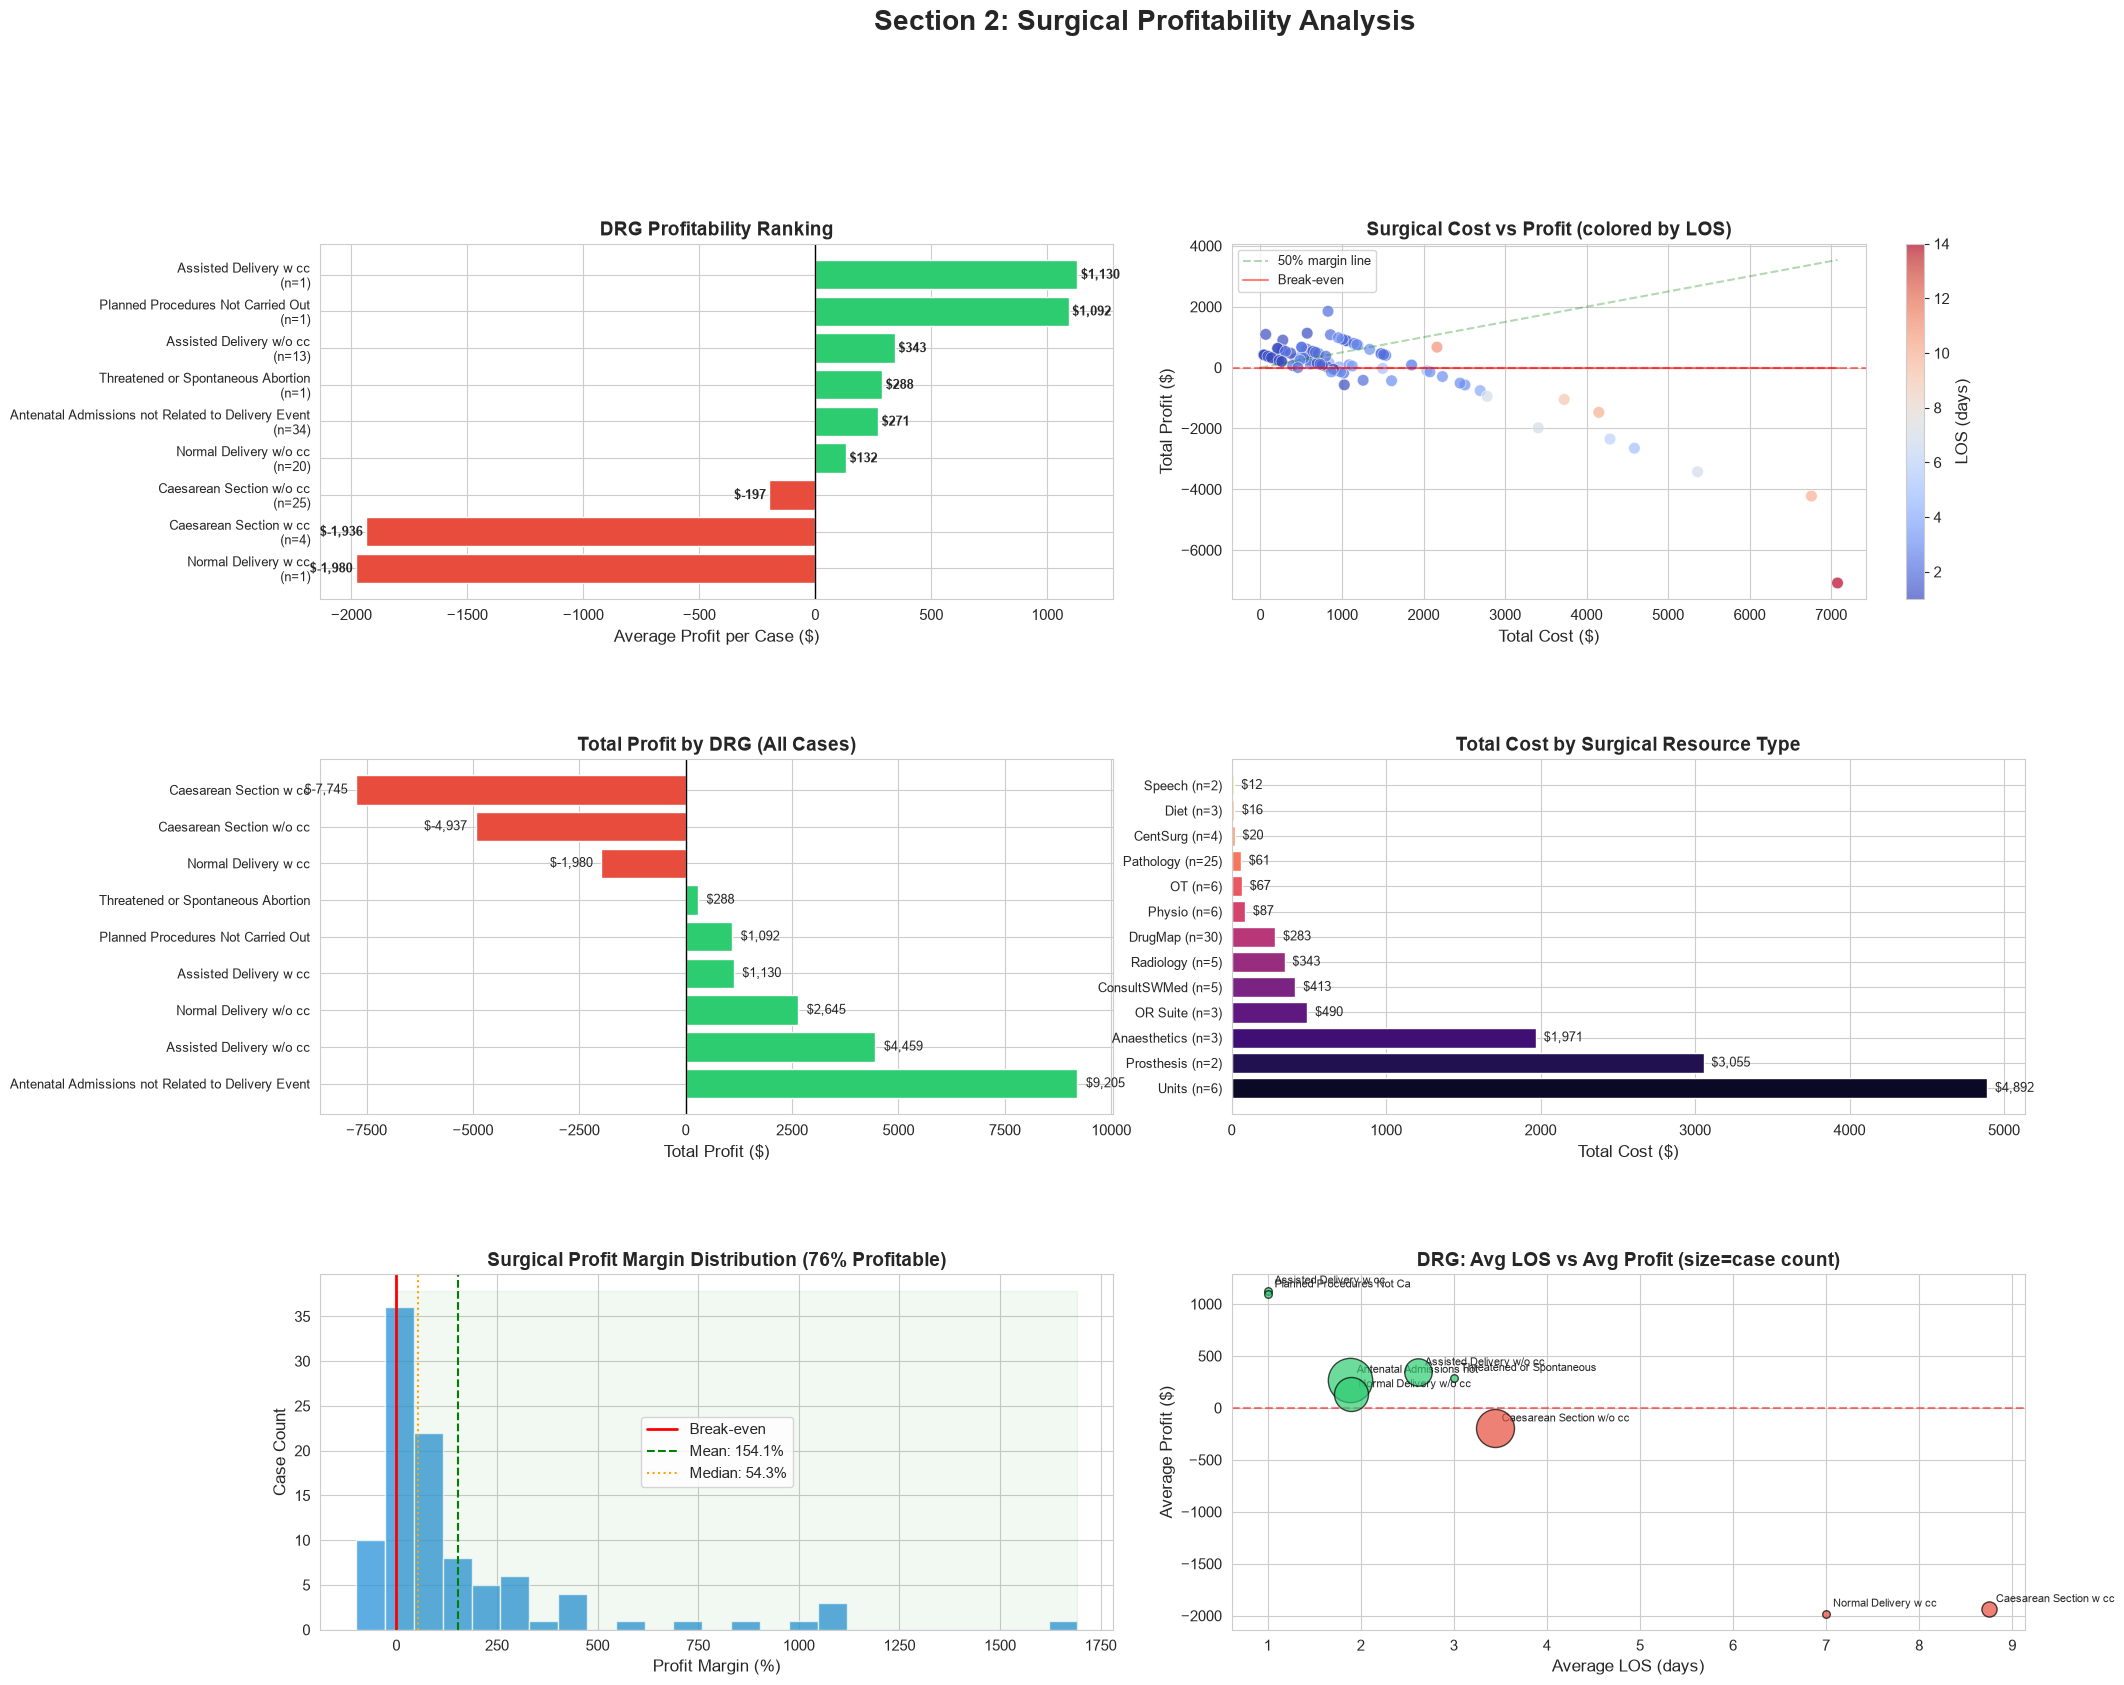

In [5]:
fig = plt.figure(figsize=(22, 18))
gs = gridspec.GridSpec(3, 4, hspace=0.45, wspace=0.35)

# ── 2A: DRG Profitability Ranking ──
ax1 = fig.add_subplot(gs[0, 0:2])
drg_profit = surg_enc.groupby('Surgical DRG Description').agg(
    Avg_Cost=('Surgical Total Cost', 'mean'),
    Avg_Profit=('Surgical Total Profit', 'mean'),
    Count=('Surgery ID', 'count'),
    Avg_LOS=('Surgical LOS', 'mean')
).sort_values('Avg_Profit', ascending=True)
colors_drg = ['#e74c3c' if p < 0 else '#2ecc71' for p in drg_profit['Avg_Profit']]
bars = ax1.barh(range(len(drg_profit)), drg_profit['Avg_Profit'], color=colors_drg, edgecolor='white')
ax1.set_yticks(range(len(drg_profit)))
ax1.set_yticklabels([f'{name}\n(n={drg_profit.loc[name, "Count"]})' for name in drg_profit.index], fontsize=9)
for i, (name, row) in enumerate(drg_profit.iterrows()):
    offset = 15 if row['Avg_Profit'] >= 0 else -15
    ha = 'left' if row['Avg_Profit'] >= 0 else 'right'
    ax1.text(row['Avg_Profit'] + offset, i, f'${row["Avg_Profit"]:,.0f}', va='center', ha=ha, fontsize=9, fontweight='bold')
ax1.axvline(0, color='black', linewidth=1)
ax1.set_title('DRG Profitability Ranking', fontweight='bold')
ax1.set_xlabel('Average Profit per Case ($)')

# ── 2B: Cost vs Profit Scatter ──
ax2 = fig.add_subplot(gs[0, 2:4])
scatter = ax2.scatter(surg_enc['Surgical Total Cost'], surg_enc['Surgical Total Profit'],
                      c=surg_enc['Surgical LOS'], cmap='coolwarm', s=70, alpha=0.7,
                      edgecolors='white', linewidth=0.5)
plt.colorbar(scatter, ax=ax2, label='LOS (days)')
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
max_cost = surg_enc['Surgical Total Cost'].max()
ax2.plot([0, max_cost], [0, max_cost * 0.5], 'g--', alpha=0.3, label='50% margin line')
ax2.plot([0, max_cost], [0, 0], 'r-', alpha=0.5, label='Break-even')
ax2.set_title('Surgical Cost vs Profit (colored by LOS)', fontweight='bold')
ax2.set_xlabel('Total Cost ($)')
ax2.set_ylabel('Total Profit ($)')
ax2.legend(fontsize=9)

# ── 2C: Revenue Waterfall ──
ax3 = fig.add_subplot(gs[1, 0:2])
drg_rev = surg_enc.groupby('Surgical DRG Description').agg(
    Total_Cost=('Surgical Total Cost', 'sum'),
    Total_Profit=('Surgical Total Profit', 'sum'),
    Count=('Surgery ID', 'count')
).sort_values('Total_Profit', ascending=False)
colors_rev = ['#2ecc71' if p > 0 else '#e74c3c' for p in drg_rev['Total_Profit']]
ax3.barh(range(len(drg_rev)), drg_rev['Total_Profit'], color=colors_rev)
ax3.set_yticks(range(len(drg_rev)))
ax3.set_yticklabels(drg_rev.index, fontsize=9)
for i, (name, row) in enumerate(drg_rev.iterrows()):
    offset = 200 if row['Total_Profit'] >= 0 else -200
    ha = 'left' if row['Total_Profit'] >= 0 else 'right'
    ax3.text(row['Total_Profit'] + offset, i, f'${row["Total_Profit"]:,.0f}', va='center', ha=ha, fontsize=9)
ax3.axvline(0, color='black', linewidth=1)
ax3.set_title('Total Profit by DRG (All Cases)', fontweight='bold')
ax3.set_xlabel('Total Profit ($)')

# ── 2D: Cost Breakdown by Resource Type ──
ax4 = fig.add_subplot(gs[1, 2:4])
resource = surg_costs.groupby('Surgical Resource Type').agg(
    Total=('Surgical Resource Cost', 'sum'),
    Avg=('Surgical Resource Cost', 'mean'),
    Count=('Surgical Resource Cost', 'count')
).sort_values('Total', ascending=False)
colors_res = sns.color_palette('magma', len(resource))
bars_res = ax4.barh(range(len(resource)), resource['Total'], color=colors_res)
ax4.set_yticks(range(len(resource)))
ax4.set_yticklabels([f'{name} (n={resource.loc[name, "Count"]})' for name in resource.index], fontsize=9)
for i, (name, row) in enumerate(resource.iterrows()):
    ax4.text(row['Total'] + 50, i, f'${row["Total"]:,.0f}', va='center', fontsize=9)
ax4.set_title('Total Cost by Surgical Resource Type', fontweight='bold')
ax4.set_xlabel('Total Cost ($)')

# ── 2E: Profit Margin Distribution ──
ax5 = fig.add_subplot(gs[2, 0:2])
pm = surg_enc['Profit Margin %'].dropna()
ax5.hist(pm, bins=25, color='#3498db', edgecolor='white', alpha=0.8)
ax5.axvline(0, color='red', linestyle='-', linewidth=2, label='Break-even')
ax5.axvline(pm.mean(), color='green', linestyle='--', linewidth=1.5, label=f'Mean: {pm.mean():.1f}%')
ax5.axvline(pm.median(), color='orange', linestyle=':', linewidth=1.5, label=f'Median: {pm.median():.1f}%')
profitable_pct = (pm > 0).mean() * 100
ax5.fill_betweenx([0, ax5.get_ylim()[1] if ax5.get_ylim()[1] > 0 else 50], 0, pm.max(), alpha=0.05, color='green')
ax5.set_title(f'Surgical Profit Margin Distribution ({profitable_pct:.0f}% Profitable)', fontweight='bold')
ax5.set_xlabel('Profit Margin (%)')
ax5.set_ylabel('Case Count')
ax5.legend()

# ── 2F: LOS vs Cost/Profit by DRG ──
ax6 = fig.add_subplot(gs[2, 2:4])
drg_scatter = surg_enc.groupby('Surgical DRG Description').agg(
    Avg_LOS=('Surgical LOS', 'mean'),
    Avg_Profit=('Surgical Total Profit', 'mean'),
    Count=('Surgery ID', 'count')
)
for name, row in drg_scatter.iterrows():
    color = '#2ecc71' if row['Avg_Profit'] > 0 else '#e74c3c'
    ax6.scatter(row['Avg_LOS'], row['Avg_Profit'], s=row['Count']*30, c=color,
                alpha=0.7, edgecolors='black', linewidth=1, zorder=5)
    ax6.annotate(name[:25], (row['Avg_LOS'], row['Avg_Profit']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax6.axhline(0, color='red', linestyle='--', alpha=0.5)
ax6.set_title('DRG: Avg LOS vs Avg Profit (size=case count)', fontweight='bold')
ax6.set_xlabel('Average LOS (days)')
ax6.set_ylabel('Average Profit ($)')

fig.suptitle('Section 2: Surgical Profitability Analysis', fontsize=20, fontweight='bold', y=1.01)
plt.show()

In [6]:
# Detailed DRG financial summary table
drg_summary = surg_enc.groupby('Surgical DRG Description').agg(
    Cases=('Surgery ID', 'count'),
    Avg_Cost=('Surgical Total Cost', 'mean'),
    Total_Cost=('Surgical Total Cost', 'sum'),
    Avg_Profit=('Surgical Total Profit', 'mean'),
    Total_Profit=('Surgical Total Profit', 'sum'),
    Avg_LOS=('Surgical LOS', 'mean'),
    Avg_Margin=('Profit Margin %', 'mean')
).sort_values('Total_Profit', ascending=False)
drg_summary['Total_Cost'] = drg_summary['Total_Cost'].round(0).astype(int)
drg_summary['Total_Profit'] = drg_summary['Total_Profit'].round(0).astype(int)
drg_summary['Avg_Cost'] = drg_summary['Avg_Cost'].round(0).astype(int)
drg_summary['Avg_Profit'] = drg_summary['Avg_Profit'].round(0).astype(int)
drg_summary['Avg_Margin'] = drg_summary['Avg_Margin'].round(1)
drg_summary['Avg_LOS'] = drg_summary['Avg_LOS'].round(1)
print('DRG Financial Summary:')
drg_summary

DRG Financial Summary:


,Cases,Avg_Cost,Total_Cost,Avg_Profit,Total_Profit,Avg_LOS,Avg_Margin
Surgical DRG Description,,,,,,,
Antenatal Admissions not Related to Delivery Event,34,401,13647,271,9205,1.9,313.8
Assisted Delivery w/o cc,13,856,11125,343,4459,2.6,73.9
Normal Delivery w/o cc,20,759,15187,132,2645,1.9,63.7
Assisted Delivery w cc,1,573,573,1130,1130,1.0,197.2
Planned Procedures Not Carried Out,1,65,65,1092,1092,1.0,1692.2
Threatened or Spontaneous Abortion,1,428,428,288,288,3.0,67.4
Normal Delivery w cc,1,3408,3408,-1980,-1980,7.0,-58.1
Caesarean Section w/o cc,25,2159,53987,-197,-4937,3.4,22.0
Caesarean Section w cc,4,3945,15782,-1936,-7745,8.8,15.0


---
## 3. Quality Measure Compliance Trends

Tracking clinical quality measures over time to identify improvement opportunities and compliance gaps.

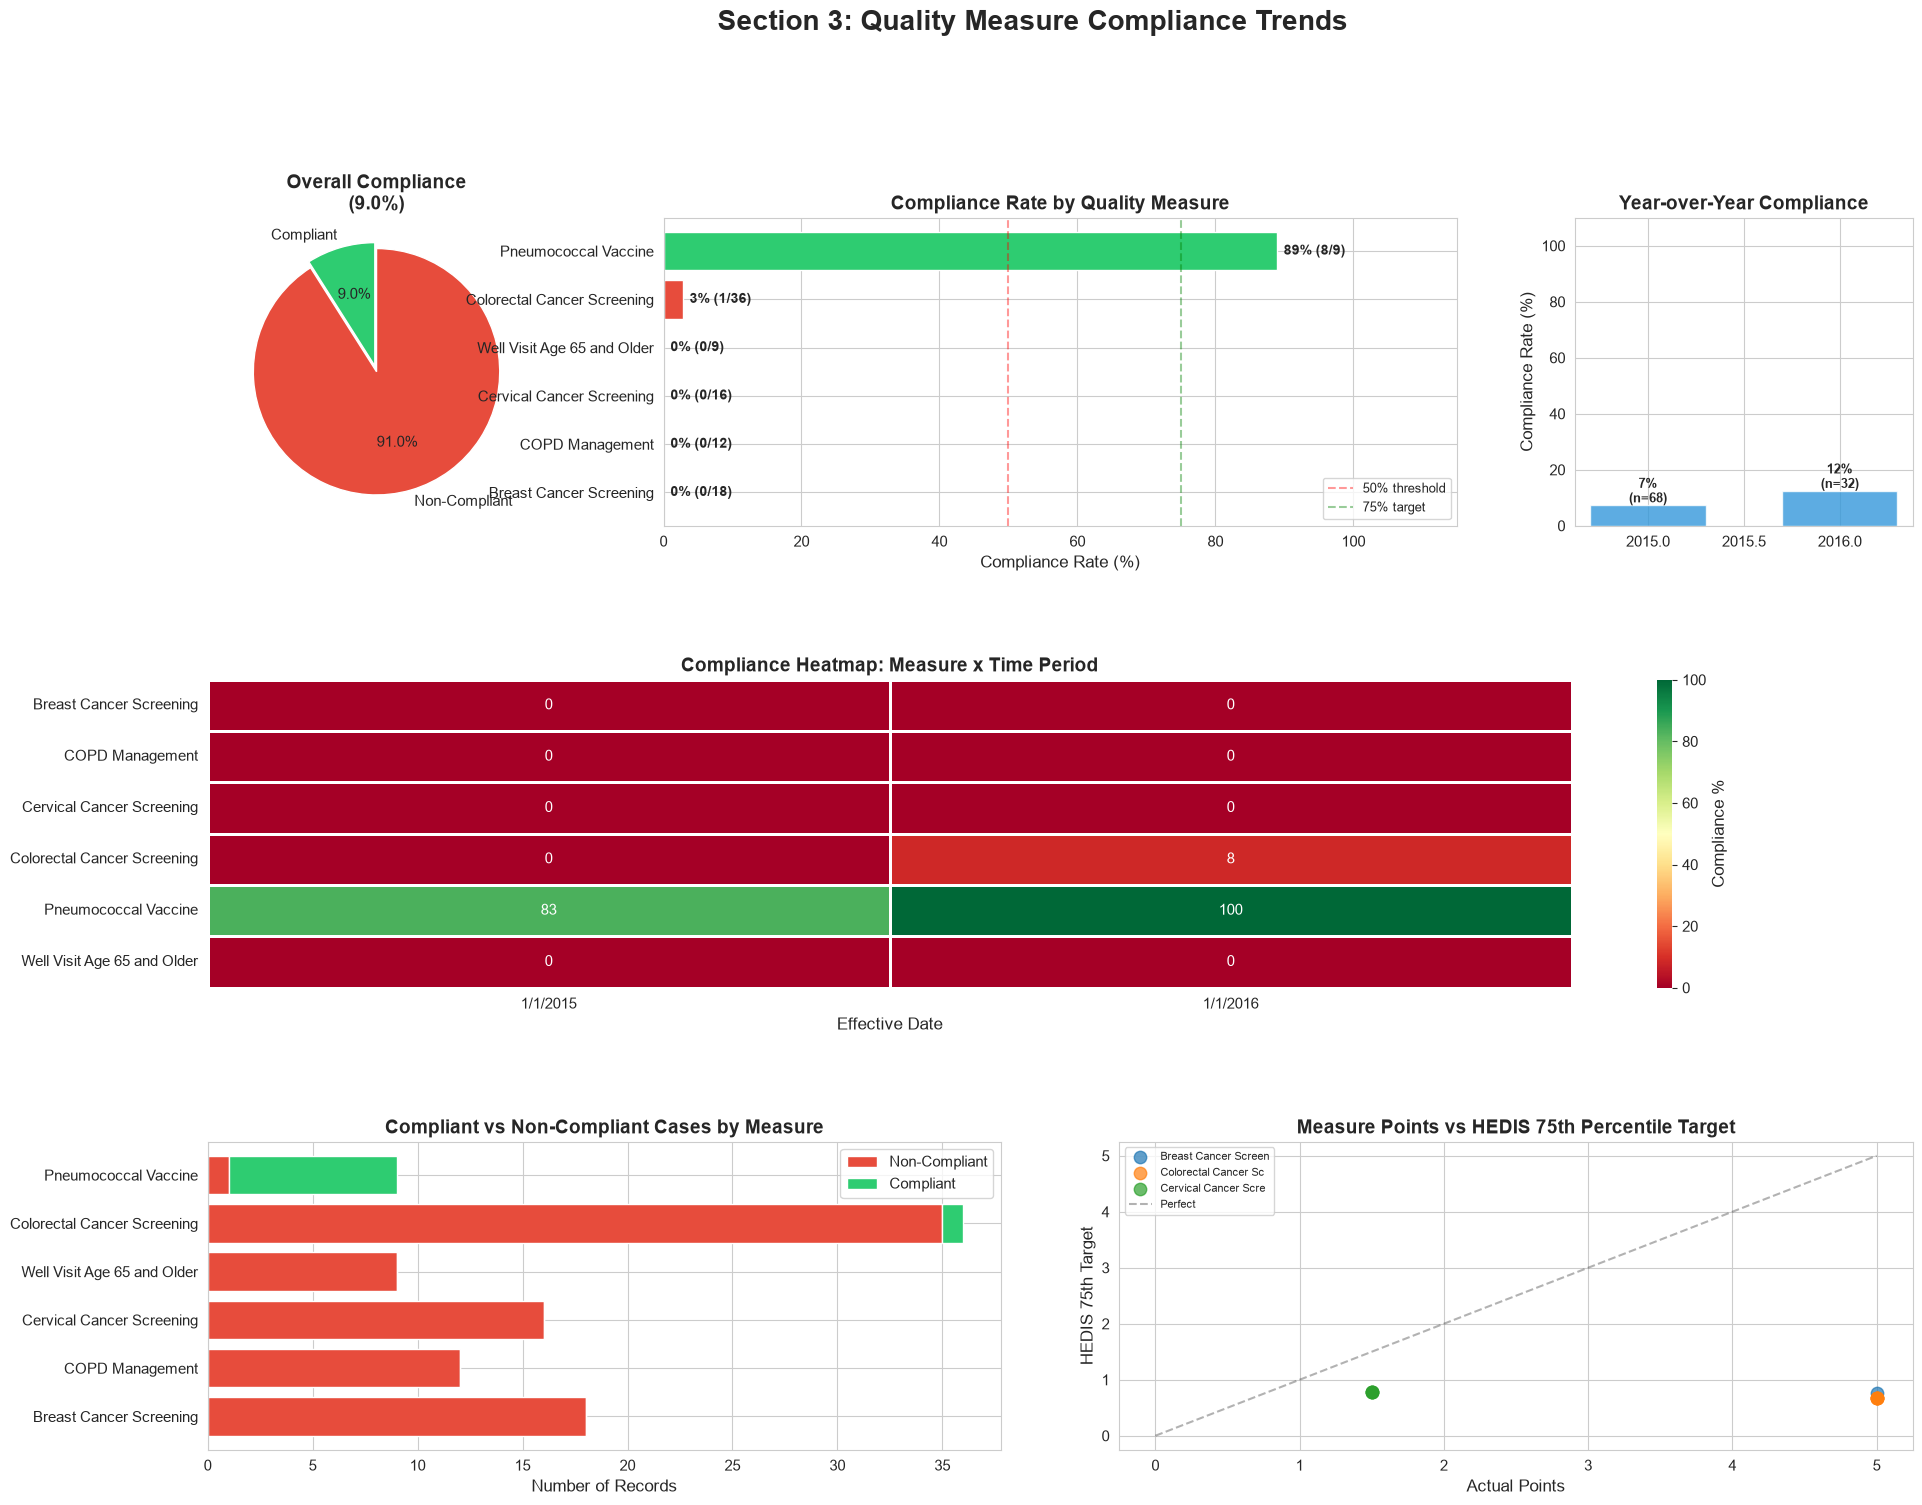

In [7]:
q = quality.copy()
q['Period'] = q['Effective Dt'].dt.to_period('Q')
q['Year'] = q['Effective Dt'].dt.year

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(3, 4, hspace=0.5, wspace=0.35)

# ── 3A: Overall Compliance Rate ──
ax1 = fig.add_subplot(gs[0, 0])
overall_comp = q['Compliant'].mean() * 100
ax1.pie([overall_comp, 100-overall_comp], labels=['Compliant', 'Non-Compliant'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90,
        explode=[0.05, 0])
ax1.set_title(f'Overall Compliance\n({overall_comp:.1f}%)', fontweight='bold')

# ── 3B: Compliance by Measure ──
ax2 = fig.add_subplot(gs[0, 1:3])
measure_comp = q.groupby('Measure Name').agg(
    Rate=('Compliant', 'mean'),
    Count=('Compliant', 'count'),
    Compliant=('Compliant', 'sum')
).sort_values('Rate', ascending=True)
colors_mc = ['#e74c3c' if r < 0.25 else '#f39c12' if r < 0.5 else '#2ecc71' for r in measure_comp['Rate']]
bars = ax2.barh(measure_comp.index, measure_comp['Rate']*100, color=colors_mc)
for bar, (_, row) in zip(bars, measure_comp.iterrows()):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{row["Rate"]*100:.0f}% ({int(row["Compliant"])}/{int(row["Count"])})',
             va='center', fontsize=10, fontweight='bold')
ax2.axvline(50, color='red', linestyle='--', alpha=0.4, label='50% threshold')
ax2.axvline(75, color='green', linestyle='--', alpha=0.4, label='75% target')
ax2.set_title('Compliance Rate by Quality Measure', fontweight='bold')
ax2.set_xlabel('Compliance Rate (%)')
ax2.set_xlim(0, 115)
ax2.legend(fontsize=9)

# ── 3C: Compliance Trend Over Time ──
ax3 = fig.add_subplot(gs[0, 3])
yearly = q.groupby('Year').agg(Rate=('Compliant', 'mean'), Count=('Compliant', 'count'))
ax3.bar(yearly.index, yearly['Rate']*100, color='#3498db', alpha=0.8, width=0.6)
for yr, row in yearly.iterrows():
    ax3.text(yr, row['Rate']*100 + 1, f'{row["Rate"]*100:.0f}%\n(n={int(row["Count"])})',
             ha='center', fontsize=9, fontweight='bold')
ax3.set_title('Year-over-Year Compliance', fontweight='bold')
ax3.set_ylabel('Compliance Rate (%)')
ax3.set_ylim(0, 110)

# ── 3D: Measure Compliance Heatmap ──
ax4 = fig.add_subplot(gs[1, 0:4])
pivot = q.groupby(['Measure Name', 'Measure Effective Date'])['Compliant'].mean().unstack(fill_value=0)
pivot.columns = [str(c.date()) if hasattr(c, 'date') else str(c) for c in pivot.columns]
sns.heatmap(pivot * 100, annot=True, fmt='.0f', cmap='RdYlGn', center=50,
            vmin=0, vmax=100, ax=ax4, linewidths=1, cbar_kws={'label': 'Compliance %'})
ax4.set_title('Compliance Heatmap: Measure x Time Period', fontweight='bold')
ax4.set_ylabel('')
ax4.set_xlabel('Effective Date')

# ── 3E: Compliant vs Non-Compliant Case Counts ──
ax5 = fig.add_subplot(gs[2, 0:2])
measure_counts = q.groupby('Measure Name').agg(
    Compliant=('Compliant', 'sum'),
    Non_Compliant=('Compliant', lambda x: len(x) - x.sum())
).sort_values('Compliant', ascending=True)
ax5.barh(measure_counts.index, measure_counts['Non_Compliant'], color='#e74c3c', label='Non-Compliant')
ax5.barh(measure_counts.index, measure_counts['Compliant'], left=measure_counts['Non_Compliant'],
         color='#2ecc71', label='Compliant')
ax5.set_title('Compliant vs Non-Compliant Cases by Measure', fontweight='bold')
ax5.set_xlabel('Number of Records')
ax5.legend()

# ── 3F: HEDIS Score Distribution ──
ax6 = fig.add_subplot(gs[2, 2:4])
hedis_data = q[q['Measure Hedis75'] > 0]
if len(hedis_data) > 0:
    for measure in hedis_data['Measure Name'].unique():
        subset = hedis_data[hedis_data['Measure Name'] == measure]
        ax6.scatter(subset['Measure Points'], subset['Measure Hedis75'],
                   s=80, alpha=0.7, label=measure[:20])
    ax6.plot([0, q['Measure Points'].max()], [0, q['Measure Points'].max()], 'k--', alpha=0.3, label='Perfect')
    ax6.set_title('Measure Points vs HEDIS 75th Percentile Target', fontweight='bold')
    ax6.set_xlabel('Actual Points')
    ax6.set_ylabel('HEDIS 75th Target')
    ax6.legend(fontsize=8, loc='upper left')
else:
    ax6.text(0.5, 0.5, 'HEDIS data\nnot available', ha='center', va='center', fontsize=14, transform=ax6.transAxes)
    ax6.set_title('HEDIS Score Distribution', fontweight='bold')

fig.suptitle('Section 3: Quality Measure Compliance Trends', fontsize=20, fontweight='bold', y=1.01)
plt.show()

---
## 4. Patient Demographic Risk Stratification

Identifying high-risk patient segments by combining demographics, LACE scores, and clinical indicators.

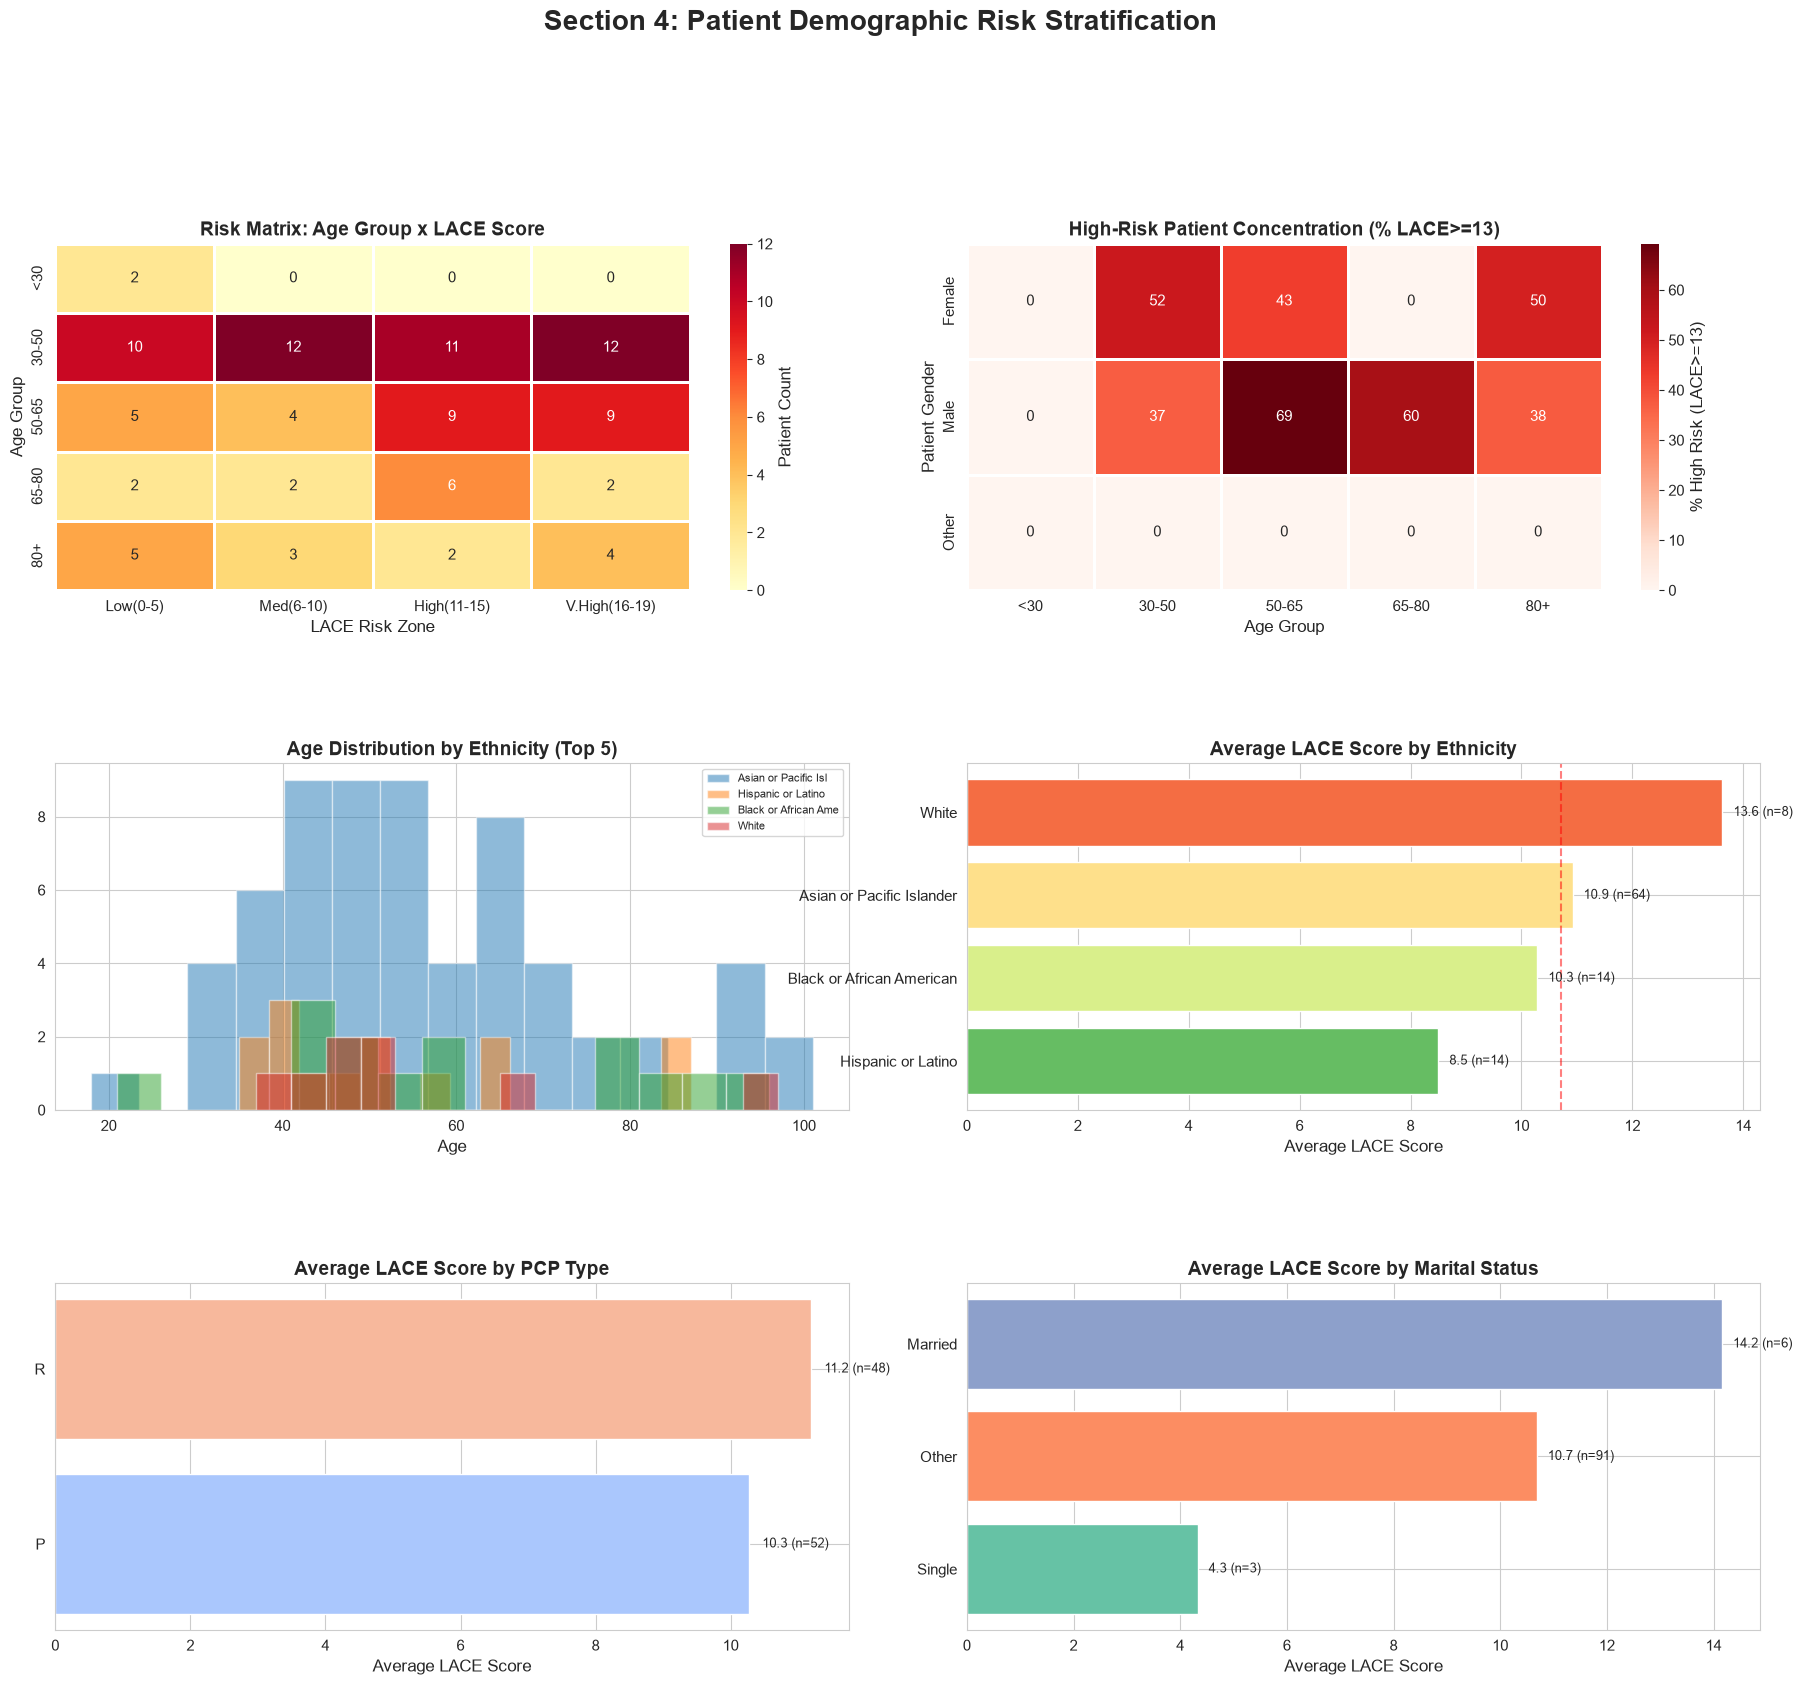

In [8]:
fig = plt.figure(figsize=(22, 18))
gs = gridspec.GridSpec(3, 4, hspace=0.5, wspace=0.35)

# ── 4A: Risk Stratification Matrix (Age Group x LACE) ──
ax1 = fig.add_subplot(gs[0, 0:2])
risk_matrix = patients.groupby(['Age Group', pd.cut(patients['Patient LACE Score'],
    bins=[-1, 5, 10, 15, 19], labels=['Low(0-5)', 'Med(6-10)', 'High(11-15)', 'V.High(16-19)'])],
    observed=False).size().unstack(fill_value=0)
sns.heatmap(risk_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=1, ax=ax1,
            cbar_kws={'label': 'Patient Count'})
ax1.set_title('Risk Matrix: Age Group x LACE Score', fontweight='bold')
ax1.set_xlabel('LACE Risk Zone')
ax1.set_ylabel('Age Group')

# ── 4B: Demographic Risk Profile ──
ax2 = fig.add_subplot(gs[0, 2:4])
demo_risk = patients.groupby(['Patient Gender', 'Age Group'], observed=False).agg(
    Count=('Master Patient ID', 'count'),
    Avg_LACE=('Patient LACE Score', 'mean'),
    High_Risk_Pct=('Patient LACE Score', lambda x: (x >= 13).mean() * 100)
).reset_index()
demo_risk_pivot = demo_risk.pivot_table(index='Patient Gender', columns='Age Group',
                                         values='High_Risk_Pct', fill_value=0, observed=False)
sns.heatmap(demo_risk_pivot, annot=True, fmt='.0f', cmap='Reds', linewidths=1, ax=ax2,
            cbar_kws={'label': '% High Risk (LACE>=13)'})
ax2.set_title('High-Risk Patient Concentration (% LACE>=13)', fontweight='bold')

# ── 4C: Age Distribution by Ethnicity ──
ax3 = fig.add_subplot(gs[1, 0:2])
top_eth = patients['Patient Ethnicity'].value_counts().head(5).index
eth_data = patients[patients['Patient Ethnicity'].isin(top_eth)]
for eth in top_eth:
    subset = eth_data[eth_data['Patient Ethnicity'] == eth]['Age'].dropna()
    ax3.hist(subset, bins=15, alpha=0.5, label=eth[:20])
ax3.set_title('Age Distribution by Ethnicity (Top 5)', fontweight='bold')
ax3.set_xlabel('Age')
ax3.legend(fontsize=8)

# ── 4D: LACE Score by Ethnicity ──
ax4 = fig.add_subplot(gs[1, 2:4])
eth_lace = patients.groupby('Patient Ethnicity').agg(
    Avg_LACE=('Patient LACE Score', 'mean'),
    High_Risk=('Patient LACE Score', lambda x: (x >= 13).mean() * 100),
    Count=('Patient LACE Score', 'count')
).sort_values('Avg_LACE', ascending=True)
ax4.barh(eth_lace.index, eth_lace['Avg_LACE'], color=sns.color_palette('RdYlGn_r', len(eth_lace)))
for i, (name, row) in enumerate(eth_lace.iterrows()):
    ax4.text(row['Avg_LACE'] + 0.2, i, f'{row["Avg_LACE"]:.1f} (n={int(row["Count"])})',
             va='center', fontsize=9)
ax4.axvline(patients['Patient LACE Score'].mean(), color='red', linestyle='--', alpha=0.5)
ax4.set_title('Average LACE Score by Ethnicity', fontweight='bold')
ax4.set_xlabel('Average LACE Score')

# ── 4E: PCP Type vs Risk ──
ax5 = fig.add_subplot(gs[2, 0:2])
pcp_risk = patients.groupby('Patient PCP Type').agg(
    Avg_LACE=('Patient LACE Score', 'mean'),
    High_Risk=('Patient LACE Score', lambda x: (x >= 13).mean() * 100),
    Count=('Patient LACE Score', 'count')
).sort_values('Avg_LACE', ascending=True)
ax5.barh(pcp_risk.index, pcp_risk['Avg_LACE'], color=sns.color_palette('coolwarm', len(pcp_risk)))
for i, (name, row) in enumerate(pcp_risk.iterrows()):
    ax5.text(row['Avg_LACE'] + 0.2, i, f'{row["Avg_LACE"]:.1f} (n={int(row["Count"])})',
             va='center', fontsize=9)
ax5.set_title('Average LACE Score by PCP Type', fontweight='bold')
ax5.set_xlabel('Average LACE Score')

# ── 4F: Marital Status vs Risk ──
ax6 = fig.add_subplot(gs[2, 2:4])
marital_risk = patients.groupby('Patient Marital Status').agg(
    Avg_LACE=('Patient LACE Score', 'mean'),
    Count=('Patient LACE Score', 'count')
).sort_values('Avg_LACE', ascending=True)
ax6.barh(marital_risk.index, marital_risk['Avg_LACE'], color=sns.color_palette('Set2', len(marital_risk)))
for i, (name, row) in enumerate(marital_risk.iterrows()):
    ax6.text(row['Avg_LACE'] + 0.2, i, f'{row["Avg_LACE"]:.1f} (n={int(row["Count"])})',
             va='center', fontsize=9)
ax6.set_title('Average LACE Score by Marital Status', fontweight='bold')
ax6.set_xlabel('Average LACE Score')

fig.suptitle('Section 4: Patient Demographic Risk Stratification', fontsize=20, fontweight='bold', y=1.01)
plt.show()

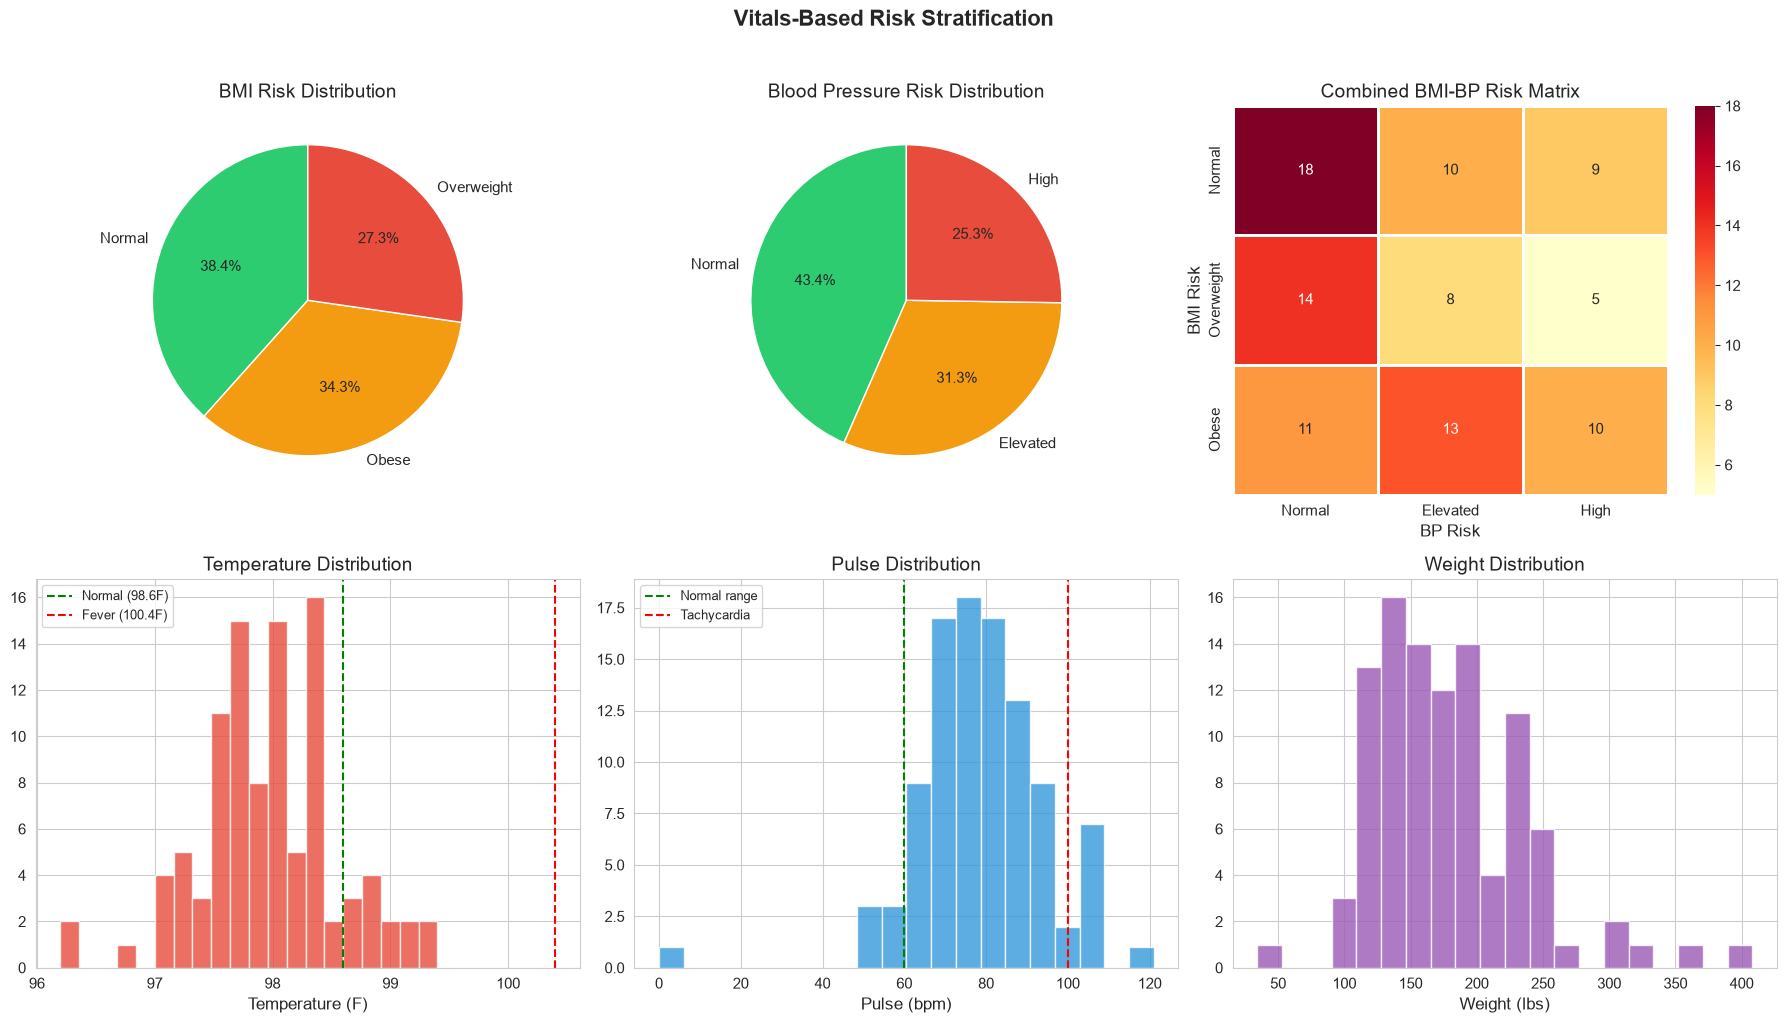

In [9]:
# Vitals-based risk stratification
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Classify vitals risk
vitals['BP Risk'] = pd.cut(vitals['BloodPressureSystolicNBR'],
                           bins=[0, 120, 140, 200], labels=['Normal', 'Elevated', 'High'])
vitals['BMI Risk'] = pd.cut(vitals['BodyMassIndexNBR'],
                            bins=[0, 25, 30, 100], labels=['Normal', 'Overweight', 'Obese'])

# 1. BMI Risk Distribution
bmi_risk = vitals['BMI Risk'].value_counts()
axes[0, 0].pie(bmi_risk, labels=bmi_risk.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
axes[0, 0].set_title('BMI Risk Distribution')

# 2. BP Risk Distribution
bp_risk = vitals['BP Risk'].value_counts()
axes[0, 1].pie(bp_risk, labels=bp_risk.index, autopct='%1.1f%%',
               colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
axes[0, 1].set_title('Blood Pressure Risk Distribution')

# 3. BMI vs BP Combined Risk
combined_risk = vitals.groupby(['BMI Risk', 'BP Risk'], observed=False).size().unstack(fill_value=0)
sns.heatmap(combined_risk, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0, 2], linewidths=1)
axes[0, 2].set_title('Combined BMI-BP Risk Matrix')

# 4. Temperature Distribution
axes[1, 0].hist(vitals['TemperatureFahrenheitNBR'].dropna(), bins=20, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(98.6, color='green', linestyle='--', label='Normal (98.6F)')
axes[1, 0].axvline(100.4, color='red', linestyle='--', label='Fever (100.4F)')
axes[1, 0].set_title('Temperature Distribution')
axes[1, 0].set_xlabel('Temperature (F)')
axes[1, 0].legend(fontsize=9)

# 5. Pulse Distribution
axes[1, 1].hist(vitals['PulseCNT'].dropna(), bins=20, color='#3498db', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(60, color='green', linestyle='--', label='Normal range')
axes[1, 1].axvline(100, color='red', linestyle='--', label='Tachycardia')
axes[1, 1].set_title('Pulse Distribution')
axes[1, 1].set_xlabel('Pulse (bpm)')
axes[1, 1].legend(fontsize=9)

# 6. Weight Distribution
axes[1, 2].hist(vitals['WeightOuncesQTY'].dropna() / 16, bins=20, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1, 2].set_title('Weight Distribution')
axes[1, 2].set_xlabel('Weight (lbs)')

plt.suptitle('Vitals-Based Risk Stratification', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Hospital Performance Benchmarking

Comparing hospitals across clinical, operational, and financial dimensions to identify best practices and improvement areas.

In [10]:
# Build hospital-level metrics
enc_h = encounters.merge(dept_hosp, on='Department ID', how='left').merge(hosp_lookup, on='Hospital ID', how='left')
enc_h = enc_h.dropna(subset=['Hospital Name'])

hosp_metrics = enc_h.groupby('Hospital Name').agg(
    Total_Encounters=('Patient Encounter ID', 'count'),
    Avg_LOS=('Patient LOS', 'mean'),
    Median_LOS=('Patient LOS', 'median'),
    ICU_Rate=('ICU', 'mean'),
    Readmit_Rate=('Readmit', 'mean'),
    Inpatient_Readmit=('Patient Inpatient Readmission Flag', lambda x: (x=='Yes').mean()),
    Avg_LACE=('Patient LOS', 'count')  # placeholder, will compute separately
)

# Add specialty diversity
spec_div = enc_h.merge(departments[['Department ID', 'Specialty Description']], on='Department ID', how='left').groupby('Hospital Name')['Specialty Description'].nunique().rename('Specialty_Count')
hosp_metrics = hosp_metrics.join(spec_div)

# Department count per hospital
dept_count = enc_h.groupby('Hospital Name')['Department ID'].nunique().rename('Dept_Count')
hosp_metrics = hosp_metrics.join(dept_count)

print('Hospital Performance Metrics:')
hosp_metrics.round(2)

Hospital Performance Metrics:


,Total_Encounters,Avg_LOS,Median_LOS,ICU_Rate,Readmit_Rate,Inpatient_Readmit,Avg_LACE,Specialty_Count,Dept_Count
Hospital Name,,,,,,,,,
Albert Einstein Medical Center,34,5.76,4.5,0.00,0.29,0.29,34,5,9
All Saints Hospital,35,8.49,6.0,0.46,0.69,0.69,35,0,2
Burn Brae Hospital,1,3.00,3.0,0.00,0.00,0.00,1,0,1
Dufur Hospital,6,3.00,2.5,0.17,0.00,0.00,6,3,4
General Hospital,24,3.00,3.0,0.04,0.21,0.21,24,2,5


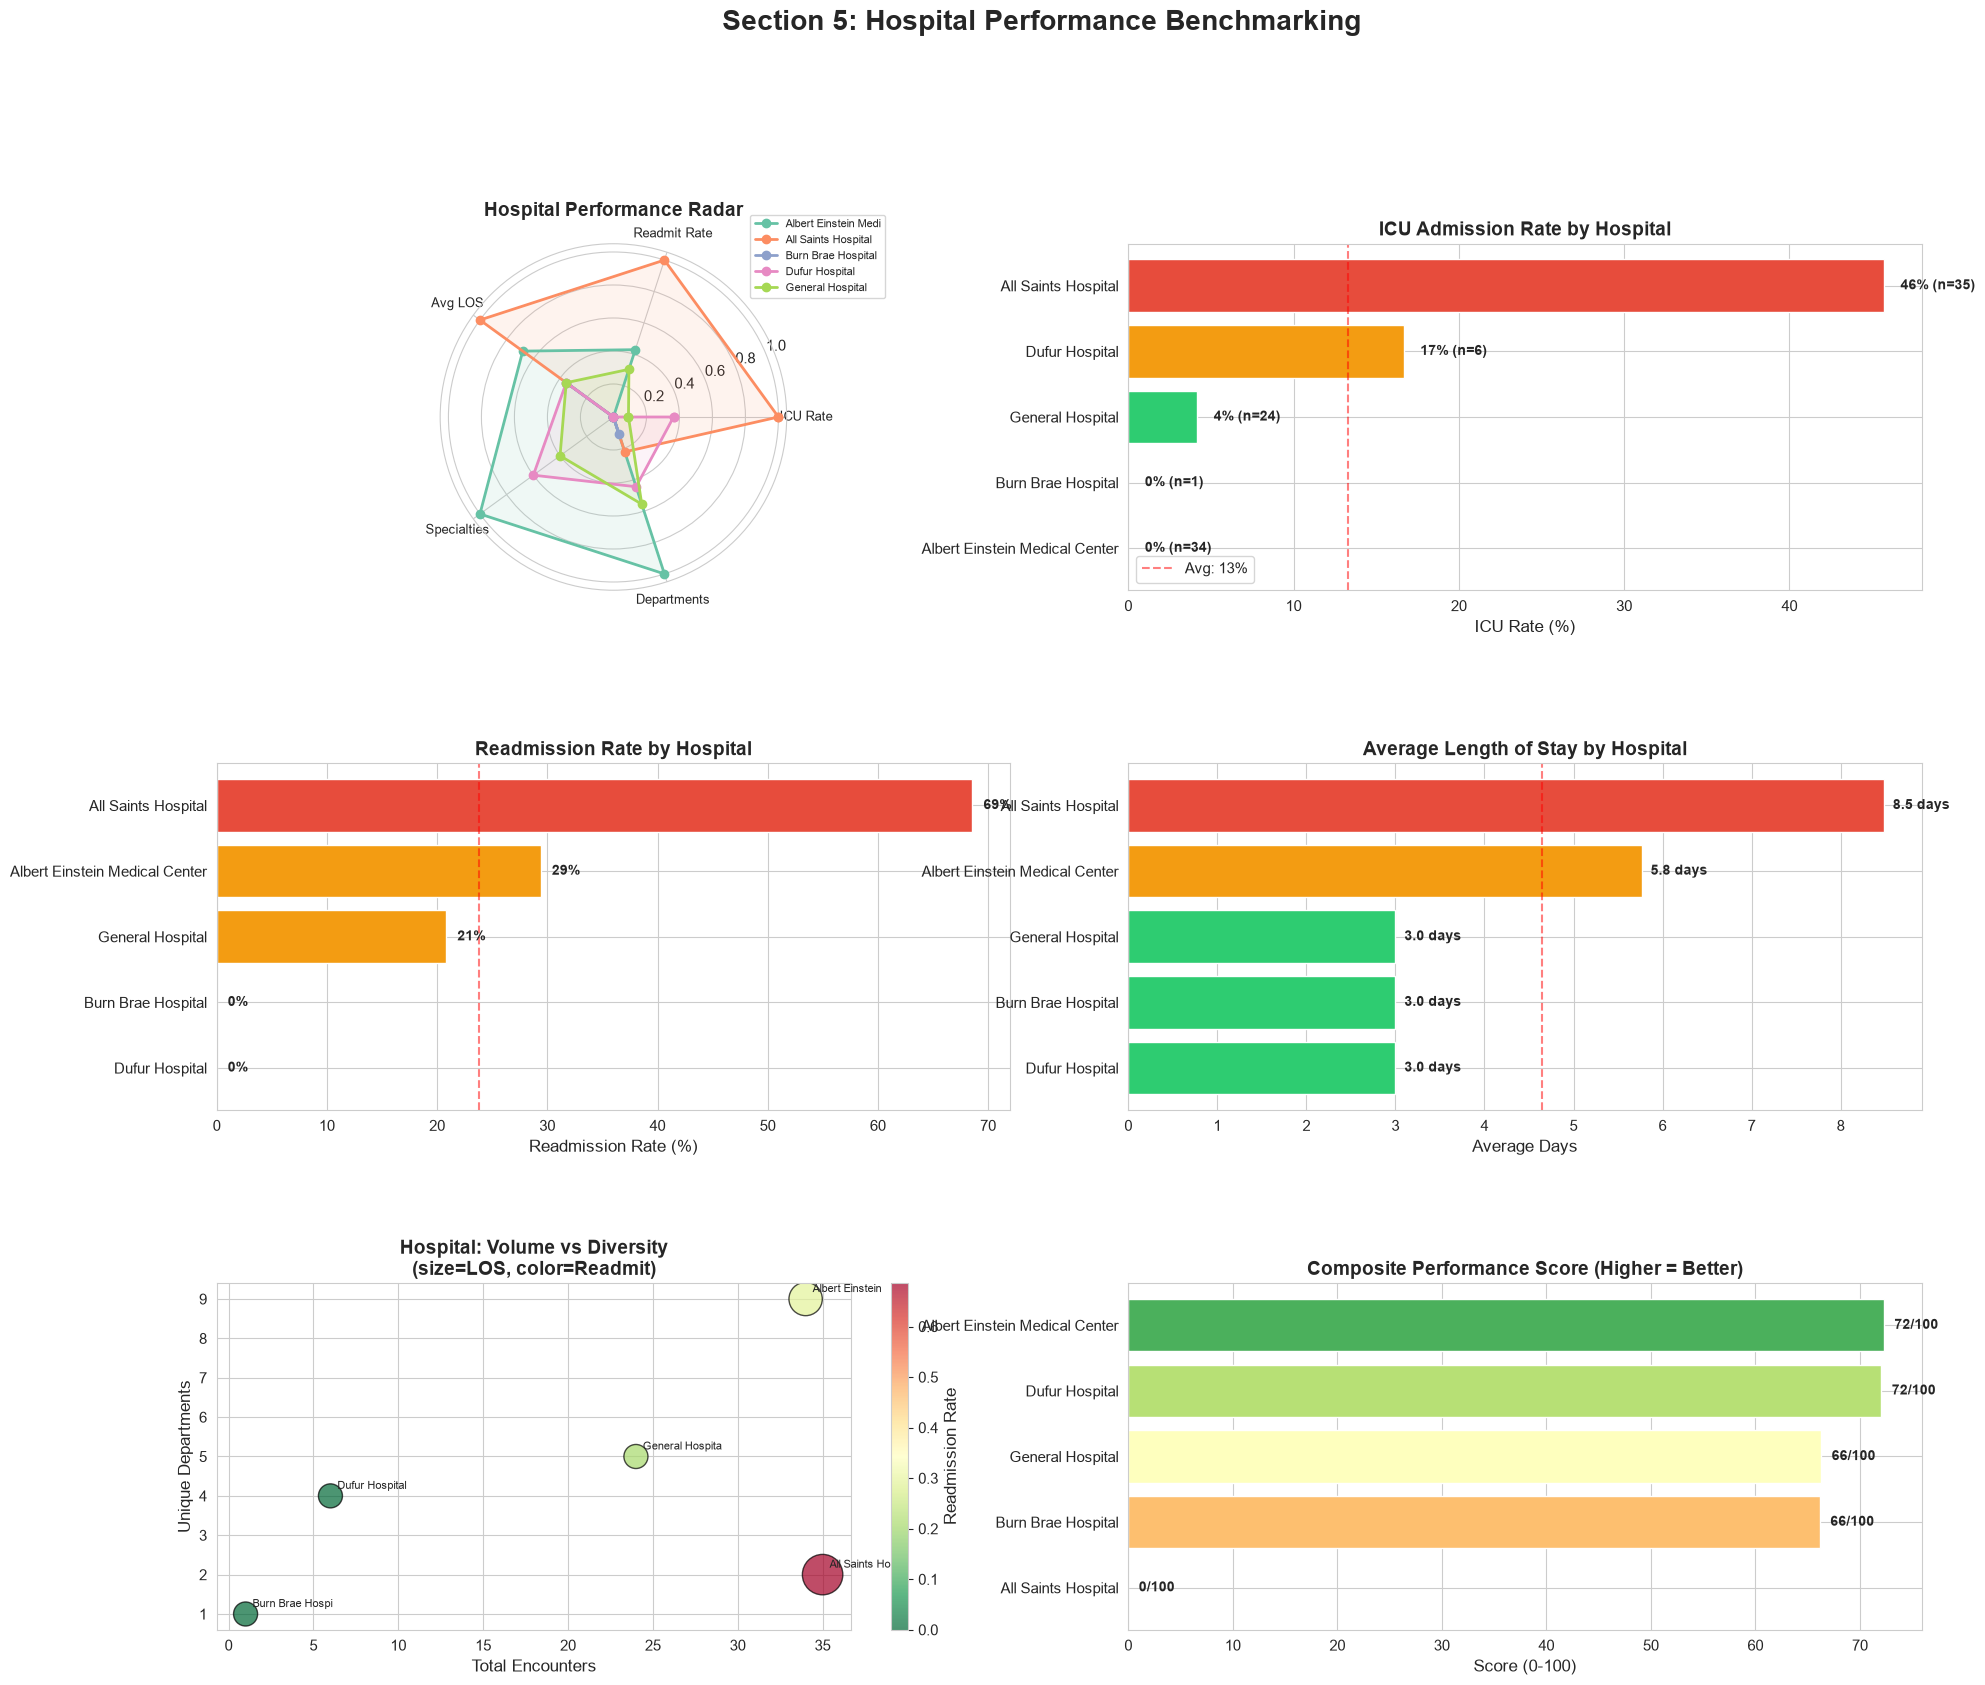

In [11]:
fig = plt.figure(figsize=(22, 18))
gs = gridspec.GridSpec(3, 4, hspace=0.5, wspace=0.35)

# ── 5A: Hospital Comparison Radar ──
ax1 = fig.add_subplot(gs[0, 0:2], polar=True)
hosp_names = hosp_metrics.index.tolist()
metrics_to_compare = ['ICU_Rate', 'Readmit_Rate', 'Avg_LOS', 'Specialty_Count', 'Dept_Count']
metric_labels = ['ICU Rate', 'Readmit Rate', 'Avg LOS', 'Specialties', 'Departments']

# Normalize for radar
radar_data = hosp_metrics[metrics_to_compare].copy()
for col in metrics_to_compare:
    max_val = radar_data[col].max()
    if max_val > 0:
        radar_data[col] = radar_data[col] / max_val

angles = np.linspace(0, 2 * np.pi, len(metrics_to_compare), endpoint=False).tolist()
angles += angles[:1]

for i, hosp in enumerate(hosp_names[:5]):
    values = radar_data.loc[hosp].values.tolist()
    values += values[:1]
    ax1.plot(angles, values, 'o-', linewidth=2, label=hosp[:20], color=PALETTE[i])
    ax1.fill(angles, values, alpha=0.1, color=PALETTE[i])

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(metric_labels, fontsize=9)
ax1.set_title('Hospital Performance Radar', fontweight='bold', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

# ── 5B: ICU Rate by Hospital ──
ax2 = fig.add_subplot(gs[0, 2:4])
hosp_sorted = hosp_metrics.sort_values('ICU_Rate', ascending=True)
colors_h = ['#e74c3c' if r > 0.3 else '#f39c12' if r > 0.1 else '#2ecc71' for r in hosp_sorted['ICU_Rate']]
bars = ax2.barh(hosp_sorted.index, hosp_sorted['ICU_Rate']*100, color=colors_h)
for bar, (_, row) in zip(bars, hosp_sorted.iterrows()):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{row["ICU_Rate"]*100:.0f}% (n={int(row["Total_Encounters"])})',
             va='center', fontsize=10, fontweight='bold')
overall_icu = hosp_metrics['ICU_Rate'].mean() * 100
ax2.axvline(overall_icu, color='red', linestyle='--', alpha=0.5, label=f'Avg: {overall_icu:.0f}%')
ax2.set_title('ICU Admission Rate by Hospital', fontweight='bold')
ax2.set_xlabel('ICU Rate (%)')
ax2.legend()

# ── 5C: Readmission Rate by Hospital ──
ax3 = fig.add_subplot(gs[1, 0:2])
hosp_sorted_r = hosp_metrics.sort_values('Readmit_Rate', ascending=True)
colors_hr = ['#e74c3c' if r > 0.4 else '#f39c12' if r > 0.2 else '#2ecc71' for r in hosp_sorted_r['Readmit_Rate']]
bars = ax3.barh(hosp_sorted_r.index, hosp_sorted_r['Readmit_Rate']*100, color=colors_hr)
for bar, (_, row) in zip(bars, hosp_sorted_r.iterrows()):
    ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{row["Readmit_Rate"]*100:.0f}%', va='center', fontsize=10, fontweight='bold')
ax3.axvline(hosp_metrics['Readmit_Rate'].mean()*100, color='red', linestyle='--', alpha=0.5)
ax3.set_title('Readmission Rate by Hospital', fontweight='bold')
ax3.set_xlabel('Readmission Rate (%)')

# ── 5D: Avg LOS by Hospital ──
ax4 = fig.add_subplot(gs[1, 2:4])
hosp_sorted_l = hosp_metrics.sort_values('Avg_LOS', ascending=True)
colors_hl = ['#e74c3c' if l > 6 else '#f39c12' if l > 4 else '#2ecc71' for l in hosp_sorted_l['Avg_LOS']]
bars = ax4.barh(hosp_sorted_l.index, hosp_sorted_l['Avg_LOS'], color=colors_hl)
for bar, (_, row) in zip(bars, hosp_sorted_l.iterrows()):
    ax4.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{row["Avg_LOS"]:.1f} days', va='center', fontsize=10, fontweight='bold')
ax4.axvline(hosp_metrics['Avg_LOS'].mean(), color='red', linestyle='--', alpha=0.5)
ax4.set_title('Average Length of Stay by Hospital', fontweight='bold')
ax4.set_xlabel('Average Days')

# ── 5E: Hospital Encounter Volume & Department Diversity ──
ax5 = fig.add_subplot(gs[2, 0:2])
scatter = ax5.scatter(hosp_metrics['Total_Encounters'], hosp_metrics['Dept_Count'],
                      s=hosp_metrics['Avg_LOS']*100, c=hosp_metrics['Readmit_Rate'],
                      cmap='RdYlGn_r', alpha=0.7, edgecolors='black', linewidth=1)
plt.colorbar(scatter, ax=ax5, label='Readmission Rate')
for name, row in hosp_metrics.iterrows():
    ax5.annotate(name[:15], (row['Total_Encounters'], row['Dept_Count']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
ax5.set_title('Hospital: Volume vs Diversity\n(size=LOS, color=Readmit)', fontweight='bold')
ax5.set_xlabel('Total Encounters')
ax5.set_ylabel('Unique Departments')

# ── 5F: Composite Performance Score ──
ax6 = fig.add_subplot(gs[2, 2:4])
# Score: lower is better (invert rates, LOS)
perf_score = pd.DataFrame(index=hosp_metrics.index)
perf_score['ICU Score'] = 100 - (hosp_metrics['ICU_Rate'] / hosp_metrics['ICU_Rate'].max() * 100)
perf_score['Readmit Score'] = 100 - (hosp_metrics['Readmit_Rate'] / hosp_metrics['Readmit_Rate'].max() * 100)
perf_score['LOS Score'] = 100 - (hosp_metrics['Avg_LOS'] / hosp_metrics['Avg_LOS'].max() * 100)
perf_score['Diversity Score'] = hosp_metrics['Specialty_Count'] / hosp_metrics['Specialty_Count'].max() * 100
perf_score['Composite'] = perf_score.mean(axis=1)
perf_score = perf_score.sort_values('Composite', ascending=True)

colors_perf = sns.color_palette('RdYlGn', len(perf_score))
bars = ax6.barh(perf_score.index, perf_score['Composite'], color=colors_perf)
for bar, (_, row) in zip(bars, perf_score.iterrows()):
    ax6.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{row["Composite"]:.0f}/100', va='center', fontsize=10, fontweight='bold')
ax6.set_title('Composite Performance Score (Higher = Better)', fontweight='bold')
ax6.set_xlabel('Score (0-100)')

fig.suptitle('Section 5: Hospital Performance Benchmarking', fontsize=20, fontweight='bold', y=1.01)
plt.show()

---
## 6. Executive Stakeholder Dashboard

A single consolidated view combining all 5 analysis areas into actionable KPIs and strategic insights.

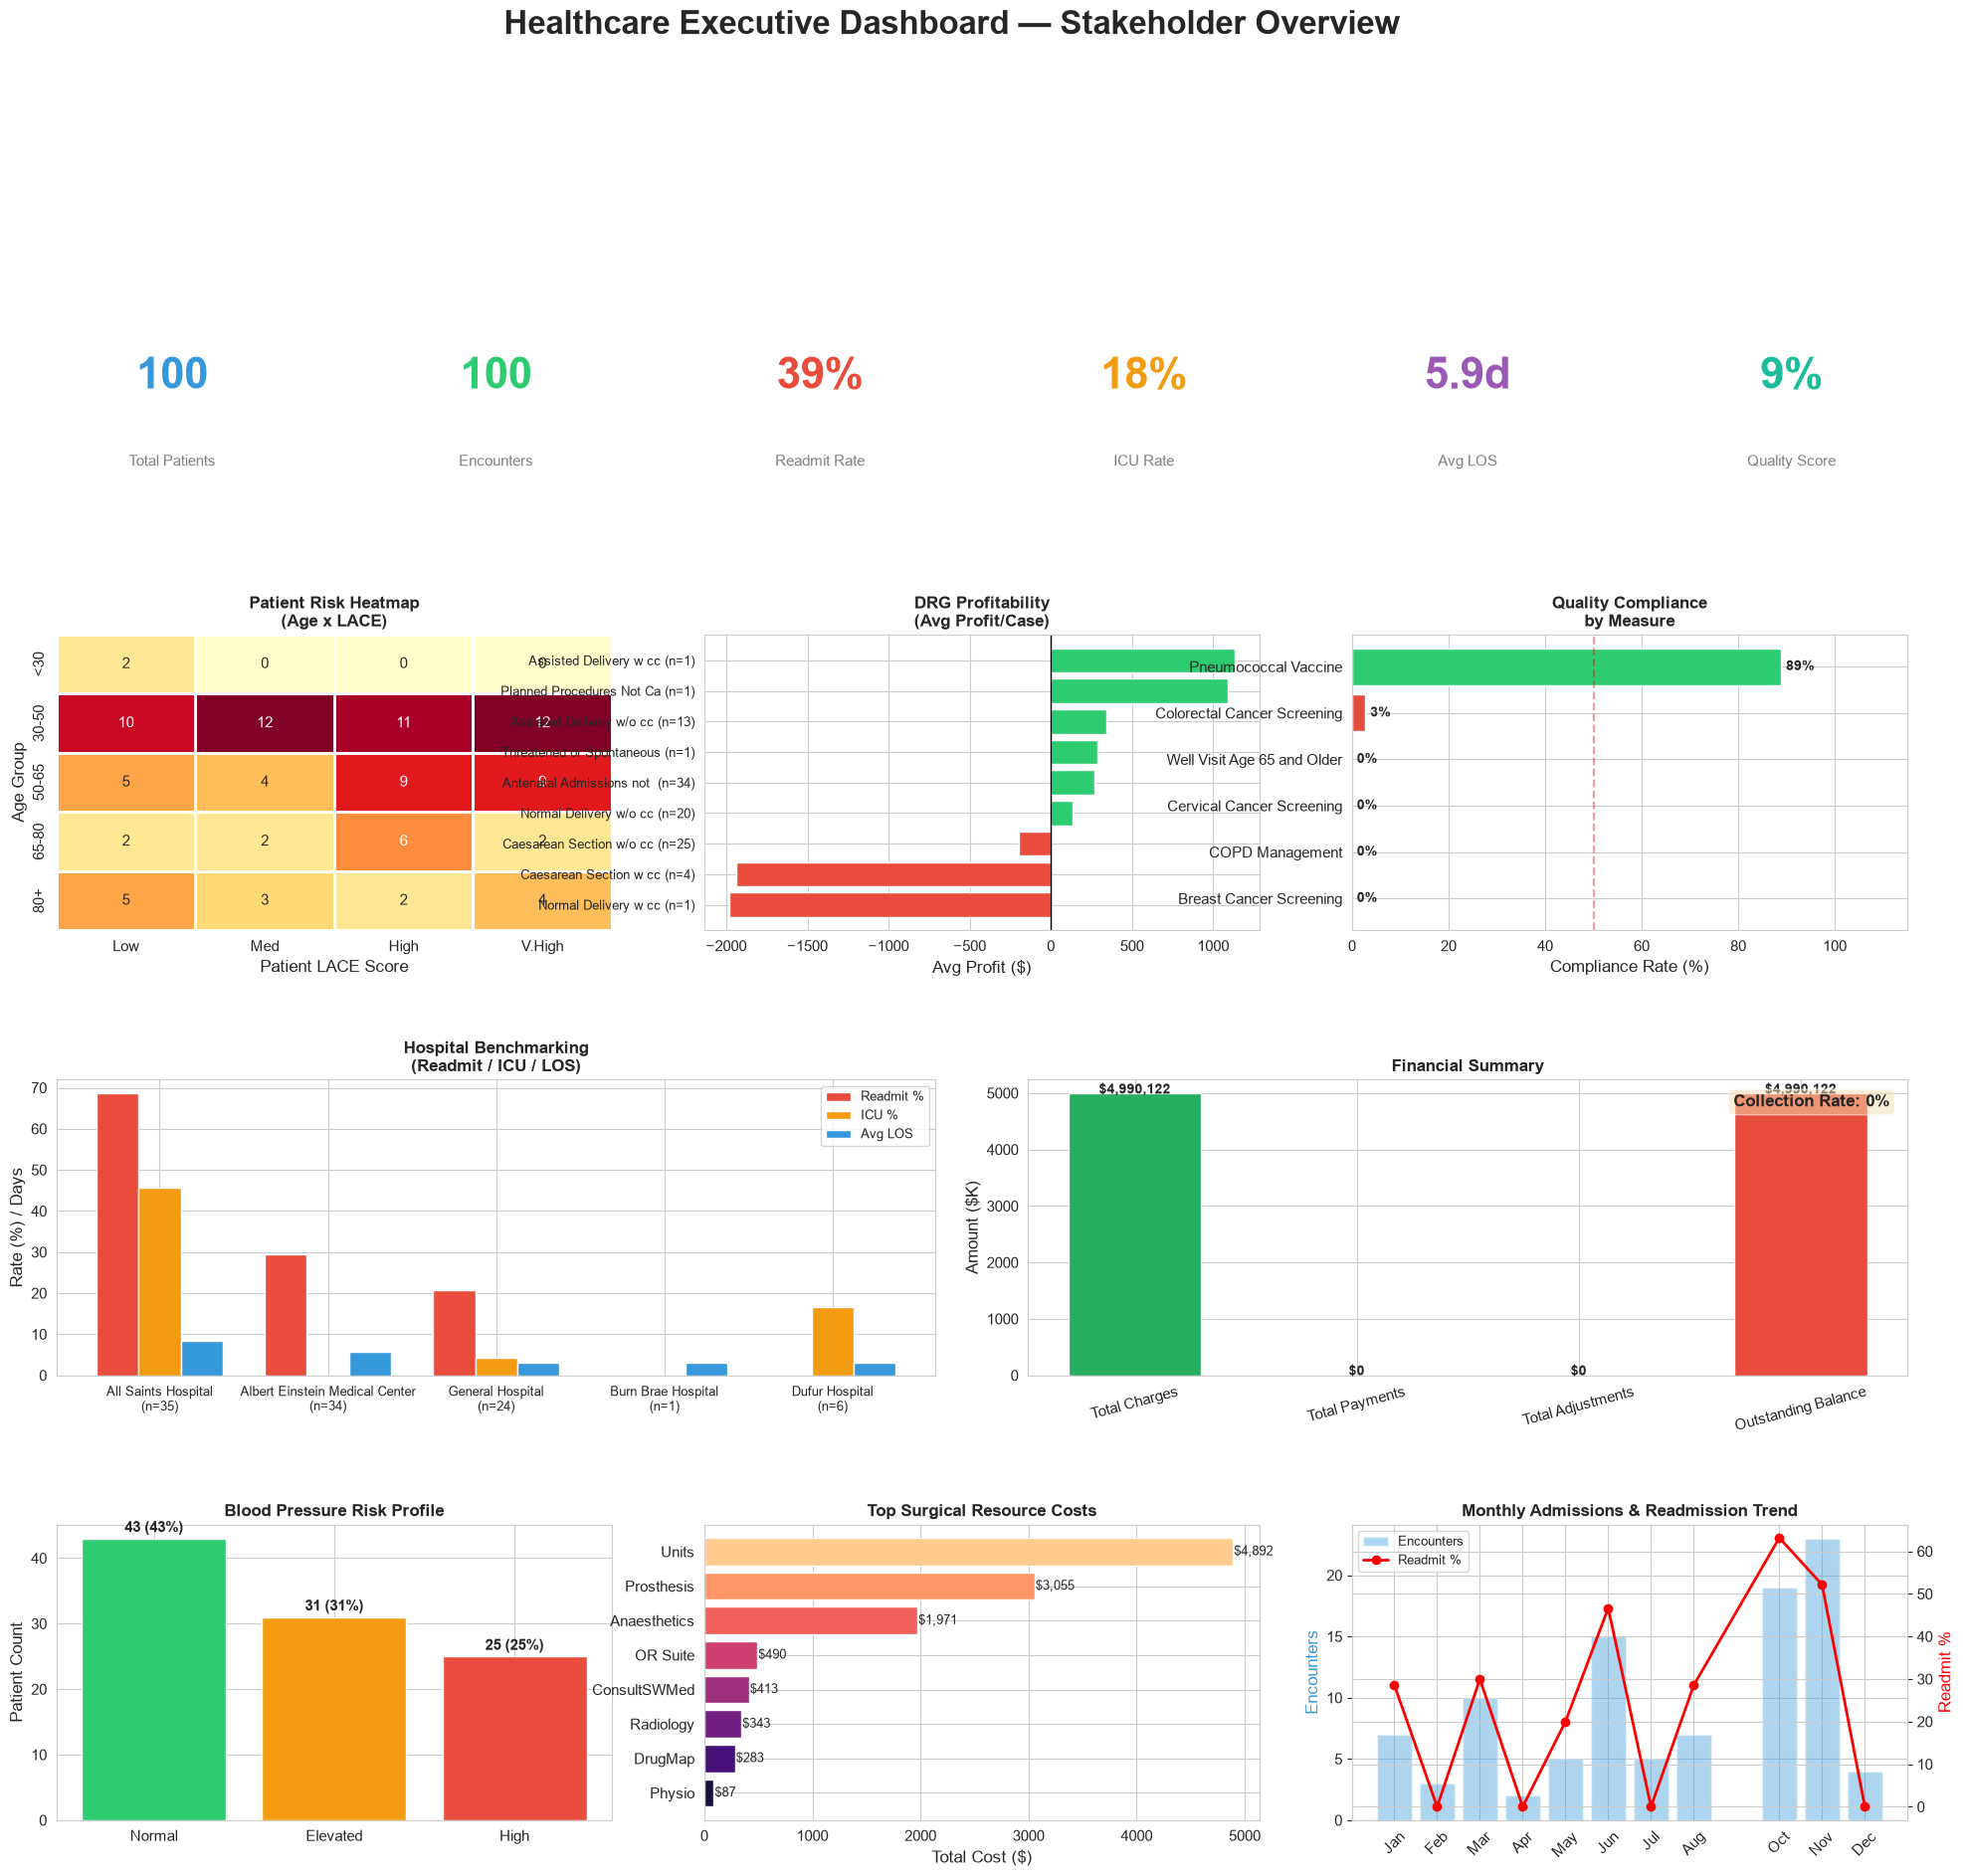

In [12]:
# ═══════════════════════════════════════════════════════════════
#  STAKEHOLDER DASHBOARD — 9-Panel Layout
# ═══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(24, 20))
gs = gridspec.GridSpec(4, 6, hspace=0.55, wspace=0.4, height_ratios=[0.8, 1.2, 1.2, 1.2])

# ── Row 0: KPI Banner ──
kpis = [
    ('Total Patients', f"{len(patients)}", '#3498db'),
    ('Encounters', f"{len(encounters)}", '#2ecc71'),
    ('Readmit Rate', f"{encounters['Readmit'].mean()*100:.0f}%", '#e74c3c'),
    ('ICU Rate', f"{encounters['ICU'].mean()*100:.0f}%", '#f39c12'),
    ('Avg LOS', f"{encounters['Patient LOS'].mean():.1f}d", '#9b59b6'),
    ('Quality Score', f"{quality['Compliant'].mean()*100:.0f}%", '#1abc9c'),
]
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.text(0.5, 0.55, value, ha='center', va='center', fontsize=32, fontweight='bold', color=color)
    ax.text(0.5, 0.12, label, ha='center', va='center', fontsize=11, color='gray')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color(color); spine.set_linewidth(2.5)

# ── Panel 1: Readmission Risk Heatmap ──
ax_p1 = fig.add_subplot(gs[1, 0:2])
risk_m = patients.groupby(['Age Group', pd.cut(patients['Patient LACE Score'],
    bins=[-1, 5, 10, 15, 19], labels=['Low', 'Med', 'High', 'V.High'])], observed=False).size().unstack(fill_value=0)
sns.heatmap(risk_m, annot=True, fmt='d', cmap='YlOrRd', ax=ax_p1, linewidths=1, cbar=False)
ax_p1.set_title('Patient Risk Heatmap\n(Age x LACE)', fontweight='bold', fontsize=12)
ax_p1.set_ylabel('Age Group')

# ── Panel 2: Surgical Profitability ──
ax_p2 = fig.add_subplot(gs[1, 2:4])
drg_p = surg_enc.groupby('Surgical DRG Description').agg(
    Avg_Profit=('Surgical Total Profit', 'mean'), Count=('Surgery ID', 'count')
).sort_values('Avg_Profit', ascending=True)
colors_dp = ['#e74c3c' if p < 0 else '#2ecc71' for p in drg_p['Avg_Profit']]
ax_p2.barh(range(len(drg_p)), drg_p['Avg_Profit'], color=colors_dp)
ax_p2.set_yticks(range(len(drg_p)))
ax_p2.set_yticklabels([f'{n[:25]} (n={drg_p.loc[n,"Count"]})' for n in drg_p.index], fontsize=9)
ax_p2.axvline(0, color='black', linewidth=1)
ax_p2.set_title('DRG Profitability\n(Avg Profit/Case)', fontweight='bold', fontsize=12)
ax_p2.set_xlabel('Avg Profit ($)')

# ── Panel 3: Quality Compliance ──
ax_p3 = fig.add_subplot(gs[1, 4:6])
mcomp = quality.groupby('Measure Name')['Compliant'].mean().sort_values(ascending=True)
colors_qc = ['#e74c3c' if r < 0.25 else '#f39c12' if r < 0.5 else '#2ecc71' for r in mcomp]
ax_p3.barh(mcomp.index, mcomp*100, color=colors_qc)
for i, (name, val) in enumerate(mcomp.items()):
    ax_p3.text(val*100 + 1, i, f'{val*100:.0f}%', va='center', fontsize=10, fontweight='bold')
ax_p3.axvline(50, color='red', linestyle='--', alpha=0.4)
ax_p3.set_title('Quality Compliance\nby Measure', fontweight='bold', fontsize=12)
ax_p3.set_xlabel('Compliance Rate (%)')
ax_p3.set_xlim(0, 115)

# ── Panel 4: Hospital Benchmark ──
ax_p4 = fig.add_subplot(gs[2, 0:3])
hosp_bench = enc_h.groupby('Hospital Name').agg(
    Readmit=('Readmit', 'mean'), ICU=('ICU', 'mean'), LOS=('Patient LOS', 'mean'), Count=('Readmit', 'count')
).sort_values('Readmit', ascending=False)
x_pos = np.arange(len(hosp_bench))
w = 0.25
ax_p4.bar(x_pos - w, hosp_bench['Readmit']*100, w, label='Readmit %', color='#e74c3c')
ax_p4.bar(x_pos, hosp_bench['ICU']*100, w, label='ICU %', color='#f39c12')
ax_p4.bar(x_pos + w, hosp_bench['LOS'], w, label='Avg LOS', color='#3498db')
ax_p4.set_xticks(x_pos)
ax_p4.set_xticklabels([f'{n}\n(n={int(hosp_bench.loc[n,"Count"])})' for n in hosp_bench.index], fontsize=9)
ax_p4.set_title('Hospital Benchmarking\n(Readmit / ICU / LOS)', fontweight='bold', fontsize=12)
ax_p4.set_ylabel('Rate (%) / Days')
ax_p4.legend(fontsize=9)

# ── Panel 5: Financial Overview ──
ax_p5 = fig.add_subplot(gs[2, 3:6])
fin_data = {
    'Total Charges': accounts['Total Account Charge $'].sum(),
    'Total Payments': accounts['Total Account Payment $'].sum(),
    'Total Adjustments': accounts['Total Account Adjustment $'].sum(),
    'Outstanding Balance': accounts['Total Account Balance $'].sum()
}
colors_fin = ['#27ae60', '#3498db', '#f39c12', '#e74c3c']
bars_fin = ax_p5.bar(fin_data.keys(), [v/1000 for v in fin_data.values()], color=colors_fin, width=0.6)
for bar, (k, v) in zip(bars_fin, fin_data.items()):
    ax_p5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
               f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')
collection_rate = fin_data['Total Payments'] / fin_data['Total Charges'] * 100
ax_p5.text(0.98, 0.95, f'Collection Rate: {collection_rate:.0f}%', transform=ax_p5.transAxes,
            ha='right', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax_p5.set_title('Financial Summary', fontweight='bold', fontsize=12)
ax_p5.set_ylabel('Amount ($K)')
ax_p5.tick_params(axis='x', rotation=15)

# ── Panel 6: Vitals Risk Summary ──
ax_p6 = fig.add_subplot(gs[3, 0:2])
bp_cat = pd.cut(vitals['BloodPressureSystolicNBR'], bins=[0, 120, 140, 200],
                labels=['Normal', 'Elevated', 'High'])
bp_counts = bp_cat.value_counts()
ax_p6.bar(bp_counts.index, bp_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
for i, (cat, val) in enumerate(bp_counts.items()):
    ax_p6.text(i, val + 1, f'{val} ({val/len(vitals)*100:.0f}%)', ha='center', fontweight='bold')
ax_p6.set_title('Blood Pressure Risk Profile', fontweight='bold', fontsize=12)
ax_p6.set_ylabel('Patient Count')

# ── Panel 7: Top Surgical Resources ──
ax_p7 = fig.add_subplot(gs[3, 2:4])
top_res = surg_costs.groupby('Surgical Resource Type')['Surgical Resource Cost'].sum().sort_values(ascending=True).tail(8)
ax_p7.barh(top_res.index, top_res.values, color=sns.color_palette('magma', len(top_res)))
for i, (name, val) in enumerate(top_res.items()):
    ax_p7.text(val + 10, i, f'${val:,.0f}', va='center', fontsize=9)
ax_p7.set_title('Top Surgical Resource Costs', fontweight='bold', fontsize=12)
ax_p7.set_xlabel('Total Cost ($)')

# ── Panel 8: Monthly Admission Trend ──
ax_p8 = fig.add_subplot(gs[3, 4:6])
monthly_trend = encounters.groupby('Month').agg(
    Readmit=('Readmit', 'mean'), Count=('Readmit', 'count')
).reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax_p8.bar(monthly_trend['Month'], monthly_trend['Count'], color='#3498db', alpha=0.4, label='Encounters')
ax8_r = ax_p8.twinx()
ax8_r.plot(monthly_trend['Month'], monthly_trend['Readmit']*100, 'ro-', linewidth=2, label='Readmit %')
ax_p8.set_xticks(monthly_trend['Month'])
ax_p8.set_xticklabels([month_names[int(m)-1] for m in monthly_trend['Month']], rotation=45)
ax_p8.set_title('Monthly Admissions & Readmission Trend', fontweight='bold', fontsize=12)
ax_p8.set_ylabel('Encounters', color='#3498db')
ax8_r.set_ylabel('Readmit %', color='red')
lines1, labels1 = ax_p8.get_legend_handles_labels()
lines2, labels2 = ax8_r.get_legend_handles_labels()
ax_p8.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

fig.suptitle('Healthcare Executive Dashboard — Stakeholder Overview',
             fontsize=24, fontweight='bold', y=1.02)
plt.show()

In [13]:
# Strategic Recommendations Summary
print('=' * 72)
print('   STRATEGIC INSIGHTS & RECOMMENDATIONS')
print('=' * 72)

high_risk_pct = (patients['Patient LACE Score'] >= 13).mean() * 100
overall_readmit = encounters['Readmit'].mean() * 100
overall_icu = encounters['ICU'].mean() * 100
collection_rate = accounts['Total Account Payment $'].sum() / accounts['Total Account Charge $'].sum() * 100
quality_rate = quality['Compliant'].mean() * 100
profitable_drgs = (surg_enc.groupby('Surgical DRG Description')['Surgical Total Profit'].mean() > 0).sum()
total_drgs = surg_enc['Surgical DRG Description'].nunique()

best_hosp = hosp_metrics['Readmit_Rate'].idxmin()
worst_hosp = hosp_metrics['Readmit_Rate'].idxmax()
best_quality = quality.groupby('Measure Name')['Compliant'].mean().idxmax()
worst_quality = quality.groupby('Measure Name')['Compliant'].mean().idxmin()

print(f"""

1. READMISSION RISK
   - {high_risk_pct:.0f}% of patients score HIGH risk (LACE >= 13)
   - Overall readmission rate: {overall_readmit:.0f}%
   - ICU patients have {'higher' if enc_h[enc_h['ICU']==1]['Readmit'].mean() > enc_h[enc_h['ICU']==0]['Readmit'].mean() else 'lower'} readmission rates
   ACTION: Prioritize discharge planning for LACE >= 13 patients

2. SURGICAL PROFITABILITY
   - {profitable_drgs}/{total_drgs} DRGs are profitable on average
   - Caesarean Sections (w/ and w/o cc) are LOSING money per case
   - Normal/Assisted Deliveries are profitable
   ACTION: Review C-section cost structure; renegotiate supply contracts

3. QUALITY COMPLIANCE
   - Overall compliance: {quality_rate:.0f}% — SIGNIFICANT GAP
   - Best: {best_quality} | Worst: {worst_quality}
   - Pneumococcal Vaccine is the ONLY measure above 50% compliance
   ACTION: Implement automated screening for cancer screenings & COPD management

4. HOSPITAL PERFORMANCE
   - Best performer: {best_hosp} (lowest readmission)
   - Needs improvement: {worst_hosp} (highest readmission)
   ACTION: Share best practices from {best_hosp} across network

5. FINANCIAL HEALTH
   - Collection rate: {collection_rate:.0f}%
   - Outstanding balance: ${accounts['Total Account Balance $'].sum():,.0f}
   ACTION: Target top 25% balance accounts for collections follow-up
""")

print('=' * 72)

   STRATEGIC INSIGHTS & RECOMMENDATIONS


1. READMISSION RISK
   - 47% of patients score HIGH risk (LACE >= 13)
   - Overall readmission rate: 39%
   - ICU patients have higher readmission rates
   ACTION: Prioritize discharge planning for LACE >= 13 patients

2. SURGICAL PROFITABILITY
   - 6/9 DRGs are profitable on average
   - Caesarean Sections (w/ and w/o cc) are LOSING money per case
   - Normal/Assisted Deliveries are profitable
   ACTION: Review C-section cost structure; renegotiate supply contracts

3. QUALITY COMPLIANCE
   - Overall compliance: 9% — SIGNIFICANT GAP
   - Best: Pneumococcal Vaccine | Worst: Breast Cancer Screening
   - Pneumococcal Vaccine is the ONLY measure above 50% compliance
   ACTION: Implement automated screening for cancer screenings & COPD management

4. HOSPITAL PERFORMANCE
   - Best performer: Burn Brae Hospital (lowest readmission)
   - Needs improvement: All Saints Hospital (highest readmission)
   ACTION: Share best practices from Burn Brae Hospit

In [14]:
conn.close()
print('Healthcare EDA v2 complete. Database connection closed.')
print('\nFiles:')
print('  Healthcare_EDA.ipynb    — v1: Overview & descriptive statistics')
print('  Healthcare_EDA_v2.ipynb — v2: Deep-dive analytics & stakeholder dashboard')

Healthcare EDA v2 complete. Database connection closed.

Files:
  Healthcare_EDA.ipynb    — v1: Overview & descriptive statistics
  Healthcare_EDA_v2.ipynb — v2: Deep-dive analytics & stakeholder dashboard
